<a href="https://colab.research.google.com/github/Mathieu-Germain/LogicMojo-AI-ML-April26-Mathieu/blob/main/linear_regression_assignment_boombikes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EXECUTIVE SUMMARY: BOOMBIKES DEMAND PREDICTION

## Strategic Rebound & Market Positioning Post-Pandemic
### Business Challenge & Context
The ongoing COVID-19 pandemic severely impacted BoomBikes, a premier US bike-sharing provider, causing substantial revenue declines. To accelerate commercial recovery immediately following the lifting of national lockdown measures, BoomBikes required an algorithmic evaluation of consumer demand patterns. This model identifies actionable revenue drivers across the American market, allowing management to efficiently allocate assets, re-engineer fleet availability, and optimize pricing mechanics to capture resurgent market share.
### Methodology & Technical Strategy
Using a historical daily dataset of bike-sharing metrics, we engineered a Multiple Linear Regression model via Python in a Google Colab environment.
  - Target Metric Definition: The model targets total daily demand (cnt), which aggregates both casual and registered subscription transactions. Administrative indexes and leaking metrics (casual, registered, instant, dteday) were removed to ensure statistical integrity.
- Categorical Realignment & Encoding: #### Numerical representations of structural factors (season, weathersit, mnth, weekday) were mapped to explicit string groups and converted via dummy coding. Utilizing drop_first=True eliminated perfect multi-collinearity, averting the Dummy Variable Trap by anchoring estimations against established baseline intercept groups.
- Model Optimization: Features were scaled via MinMax Normalization. Using an iterative training architecture, multi-collinearity was systematically neutralized by dropping variables exhibiting high Variance Inflation Factors (VIF > 5) or statistically insignificant p-values (p > 0.05).
Core Findings & Macro Dynamics
1.	Macro Market Momentum: The variable yr (Year) emerged as a powerful baseline proxy for organic customer adoption. Demand expanded sharply in 2019 compared to 2018, proving a structural upward trend in public familiarity and long-term user acquisition.
2.	Climatic & Environmental Elasticity: Bike rentals exhibit an intense correlation with ambient temperature (temp, $r \approx 0.63$). Conversely, adverse weather states—specifically light snow, scattered thunderstorms, and rain (weathersit_light_rain_snow)—introduce steep negative shocks to daily booking volume.
3.	Statistical Validity: Post-model validation confirmed linear compliance. Residual errors exhibited stable homoscedasticity across predicted parameters and formed a symmetric normal distribution centered tightly at zero, validating the predictive stability of our parameters.

## Business Implications & Operations
Management should discard expectations of uniform seasonal utilization and instead deploy dynamic operational protocols. Fleet maintenance schedules must be concentrated during early Spring or Light Snow/Rain patterns when baseline demand naturally contracts. Marketing campaigns, targeted subscription incentives, and maximum fleet deployments should scale alongside rising temperatures and peak seasons (Summer/Fall) to optimize asset turns and maximize post-lockdown revenue capture.



Step 1: Library Ingestion & Environment Configuration

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score


# For nicer plots
%matplotlib inline
sns.set_style('whitegrid')


import warnings
warnings.filterwarnings('ignore')



Step 2: Loading & Preliminary Structural Assessment
#### Import your target source dataset and inspect its basic dimensions

In [ ]:
# Load dataset and display first 5 rows
df = pd.read_csv('day.csv')

df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,1,1,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,2,1,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,3,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,4,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,5,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


Step 3: Initial Data Inspection

In [ ]:
# check dtypes, missing values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   dteday      730 non-null    object 
 2   season      730 non-null    int64  
 3   yr          730 non-null    int64  
 4   mnth        730 non-null    int64  
 5   holiday     730 non-null    int64  
 6   weekday     730 non-null    int64  
 7   workingday  730 non-null    int64  
 8   weathersit  730 non-null    int64  
 9   temp        730 non-null    float64
 10  atemp       730 non-null    float64
 11  hum         730 non-null    float64
 12  windspeed   730 non-null    float64
 13  casual      730 non-null    int64  
 14  registered  730 non-null    int64  
 15  cnt         730 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.4+ KB


In [ ]:
# statistical summary to get basic understanding of dataset

df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,365.500000,2.498630,0.500000,6.526027,0.028767,2.995890,0.690411,1.394521,20.319259,23.726322,62.765175,12.763620,849.249315,3658.757534,4508.006849
std,210.877136,1.110184,0.500343,3.450215,0.167266,2.000339,0.462641,0.544807,7.506729,8.150308,14.237589,5.195841,686.479875,1559.758728,1936.011647
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.424346,3.953480,0.000000,1.500244,2.000000,20.000000,22.000000
25%,183.250000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,13.811885,16.889713,52.000000,9.041650,316.250000,2502.250000,3169.750000
50%,365.500000,3.000000,0.500000,7.000000,0.000000,3.000000,1.000000,1.000000,20.465826,24.368225,62.625000,12.125325,717.000000,3664.500000,4548.500000
75%,547.750000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,26.880615,30.445775,72.989575,15.625589,1096.500000,4783.250000,5966.000000
max,730.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,35.328347,42.044800,97.250000,34.000021,3410.000000,6946.000000,8714.000000


In [ ]:
# To check columns present in dataset

print(df.columns)

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')


In [ ]:
# check for no missing values per column/series

df.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


## Key observations:

  - No missing values.

  - season, weathersit, mnth, weekday are encoded as integers but are categorical.

  - temp, atemp, hum, windspeed are continuous.

  - casual, registered, cnt – we keep only cnt as target.

Step 4: Data Preparation (Cleaning & Feature Engineering)

In [ ]:
# Drop non-predictive administrative or leakage columns
# 'instant' is an index, 'dteday' is redundant with year/month/weekday.
# 'casual' and 'registered' sum directly to 'cnt' and cause target leakage.

df = df.drop(['instant', 'dteday', 'atemp', 'casual', 'registered'], axis = 1)

In [ ]:
# Let see the new dataset with remaining columns

df.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,cnt
0,1,0,1,0,1,1,2,14.110847,80.5833,10.749882,985
1,1,0,1,0,2,1,2,14.902598,69.6087,16.652113,801
2,1,0,1,0,3,1,1,8.050924,43.7273,16.636703,1349
3,1,0,1,0,4,1,1,8.200000,59.0435,10.739832,1562
4,1,0,1,0,5,1,1,9.305237,43.6957,12.522300,1600


Step 5: Categorical Label Realignment

In [ ]:
# According to data dictionary
# Note: yr, holiday, workingday are already binary (0/1) and can stay as numeric.

df['season'] = df['season'].map({1:'spring', 2:'summer', 3:'fall', 4:'winter'})
df['weathersit'] = df['weathersit'].map({
    1:'clear', 2:'mist', 3:'light_snow_rain', 4:'heavy_rain_snow'
})

# df['mnth'] = df['mnth'].map({1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun', \
#                             7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'})
# df['weekday'] = df['weekday'].map({0:'Sun', 1:'Mon', 2:'Tue', 3:'Wed', \
#                                    4:'Thu', 5:'Fri', 6:'Sat'})

# mnth and weekday can be left as integers or converted to strings – we'll treat them as categorical.
# We'll convert them to strings to ensure they are encoded as dummies.
df['mnth'] = df['mnth'].astype(str)
df['weekday'] = df['weekday'].astype(str)

In [ ]:
#  One‑Hot Encoding with drop_first=True

# Create dummies for all categorical columns
df_encoded = pd.get_dummies(df, columns=['season', 'weathersit', 'mnth', 'weekday'], drop_first=True)
# Check new shape
df_encoded.shape


(730, 29)

**Why drop_first=True?** It prevents the dummy variable trap – perfect multicollinearity that would make the regression coefficients unstable. The dropped category becomes the baseline, and each coefficient represents the difference relative to that baseline.

In [ ]:
# Identify numeric columns (they are already scaled, but we'll standardise to 0-1 range for better coefficient interpretation)
numeric_cols = ['temp', 'hum', 'windspeed']
scaler = MinMaxScaler()
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

Keep yr, holiday, workingday unscaled because they are binary.

Step : Exploratory Data Analysis (EDA)

- Univariate Analysis
    - Histograms for numeric variables.
    - Count plots for categorical ones.

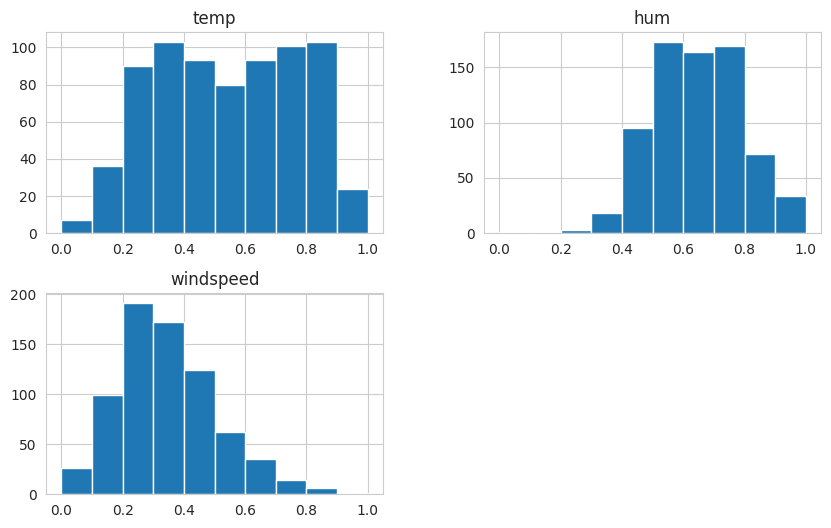

In [ ]:
# Historgrams for numeric variables

df_encoded[numeric_cols].hist(figsize=(10, 6));


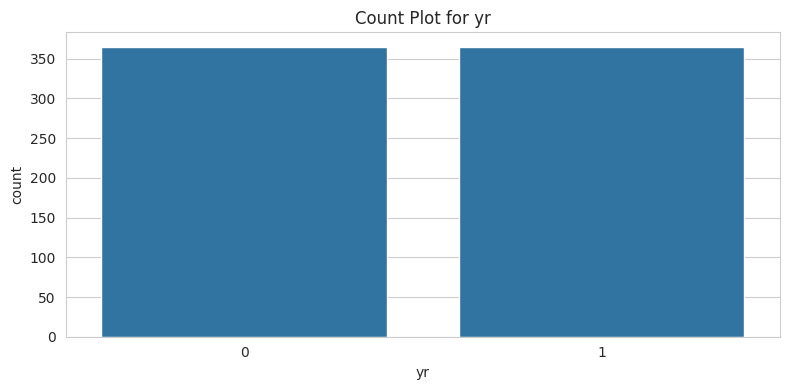

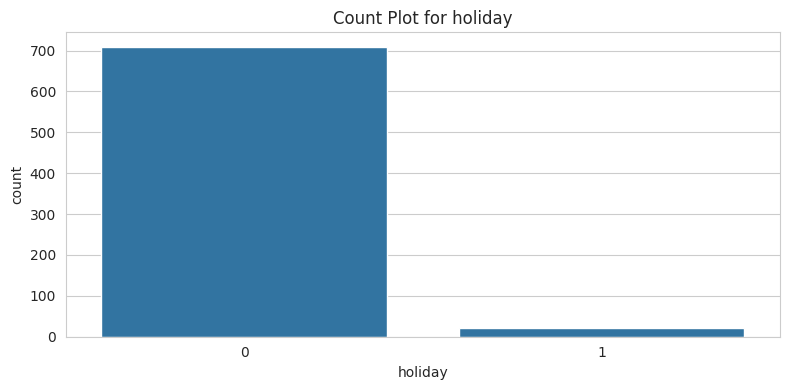

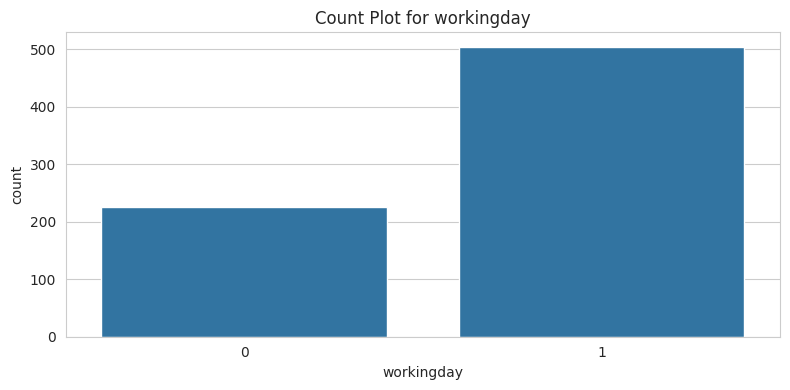

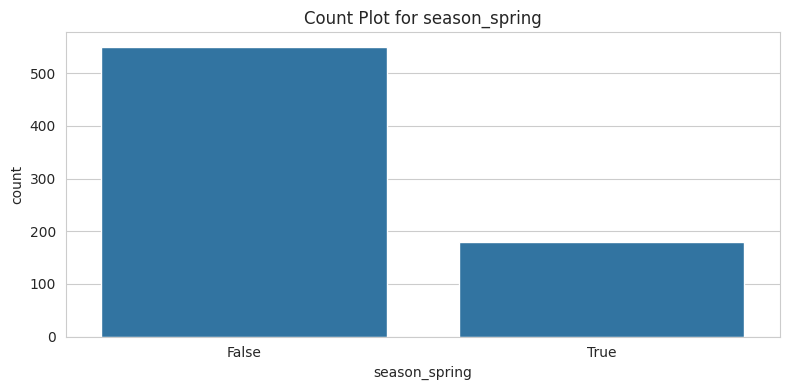

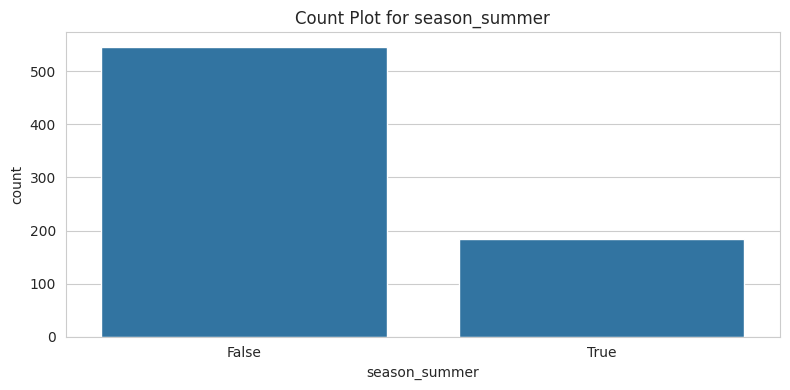

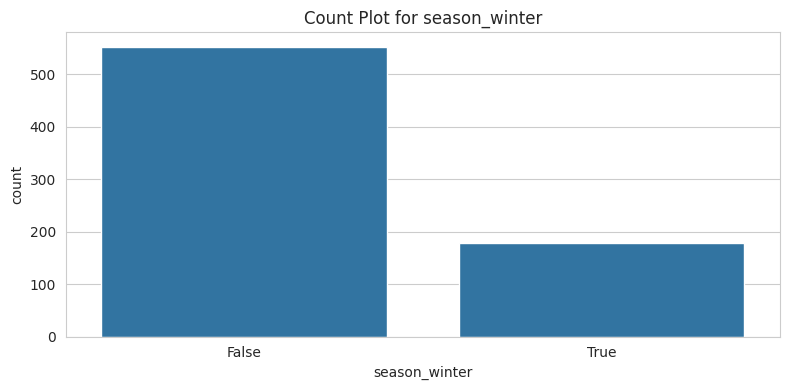

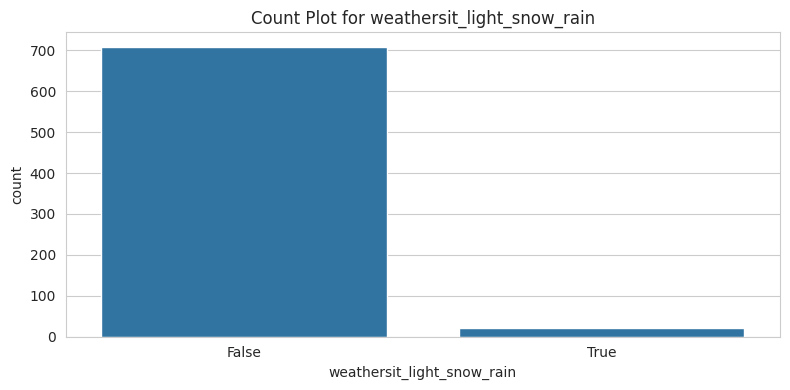

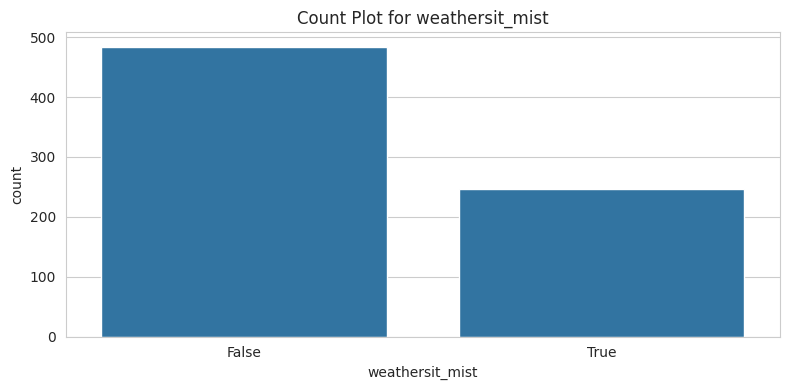

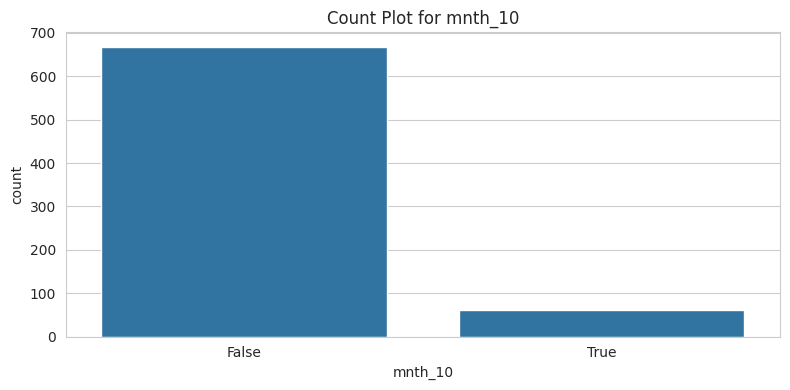

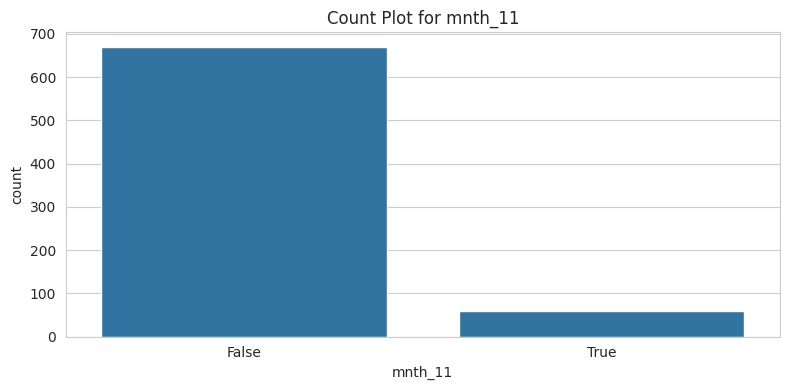

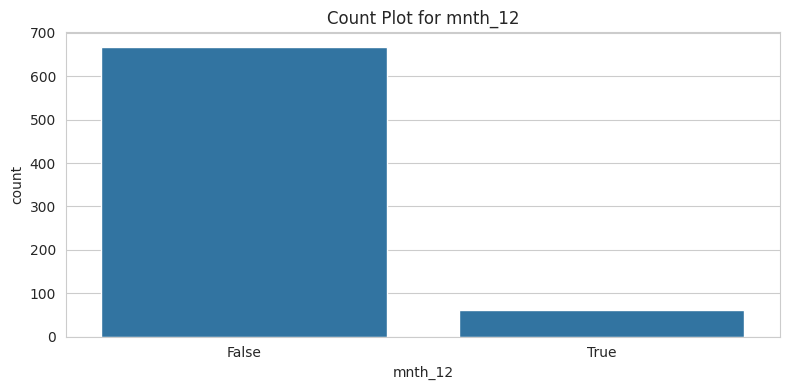

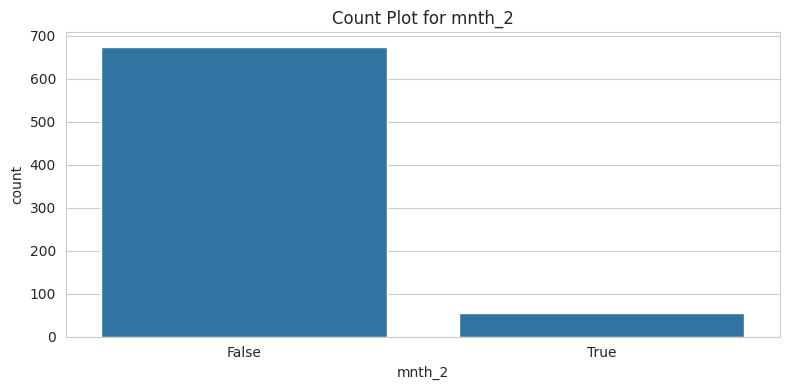

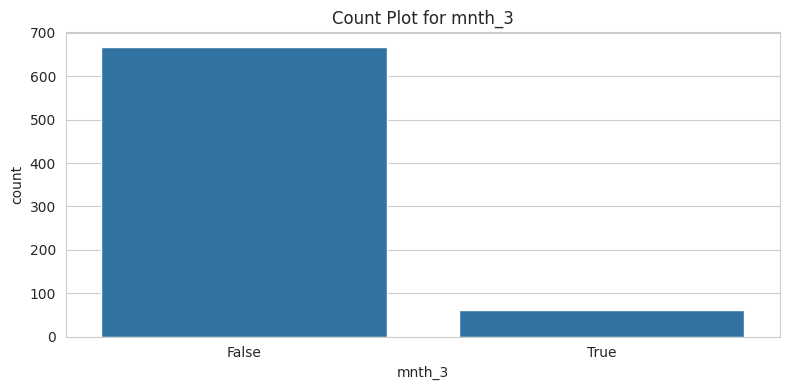

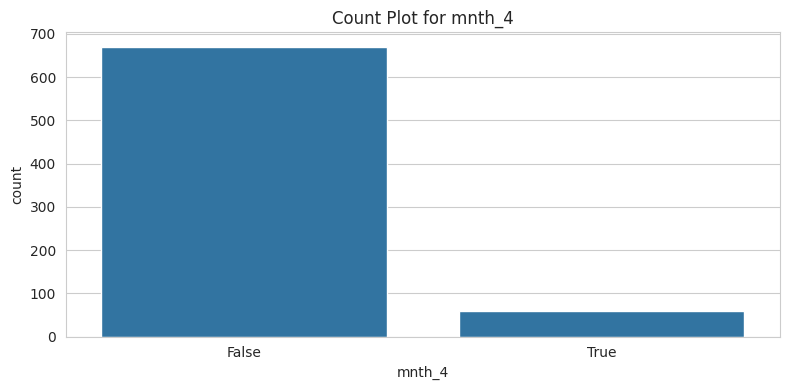

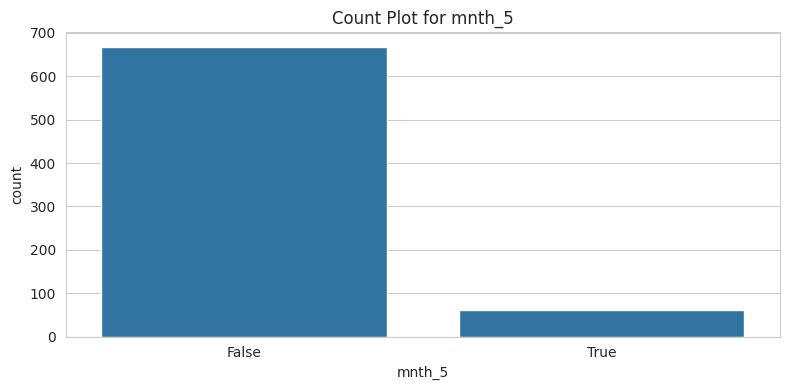

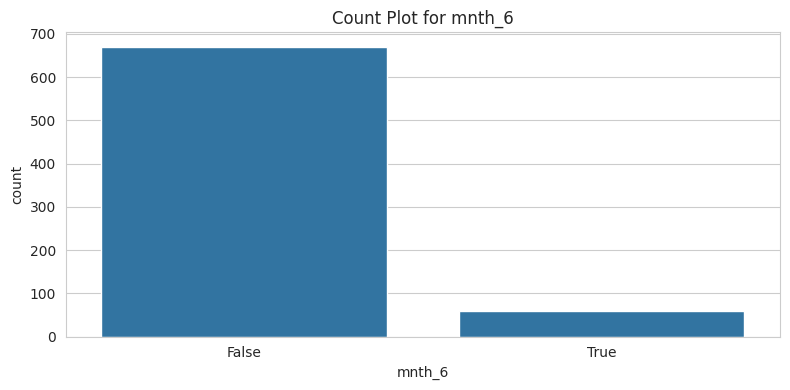

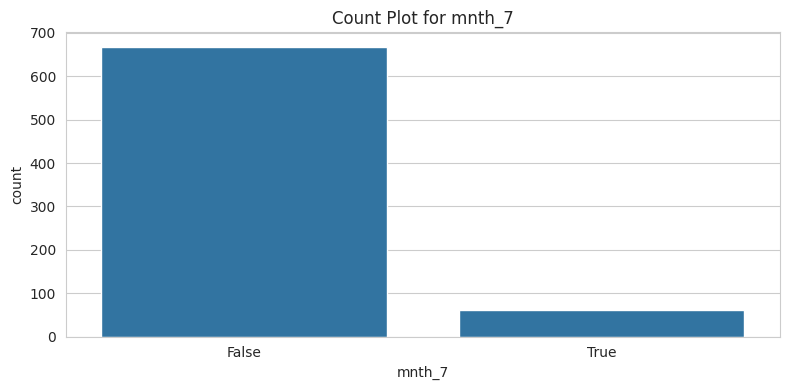

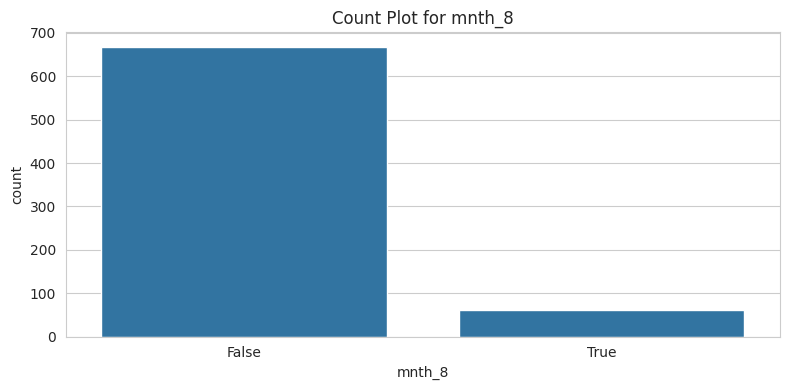

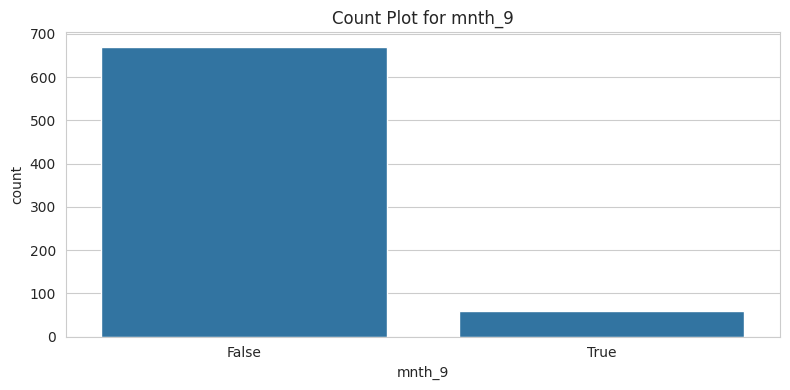

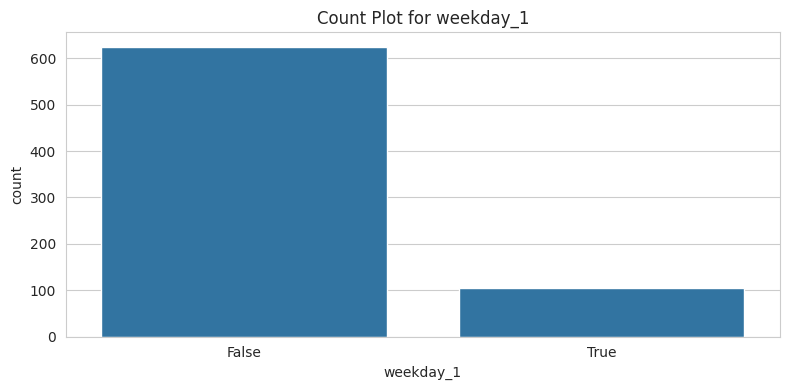

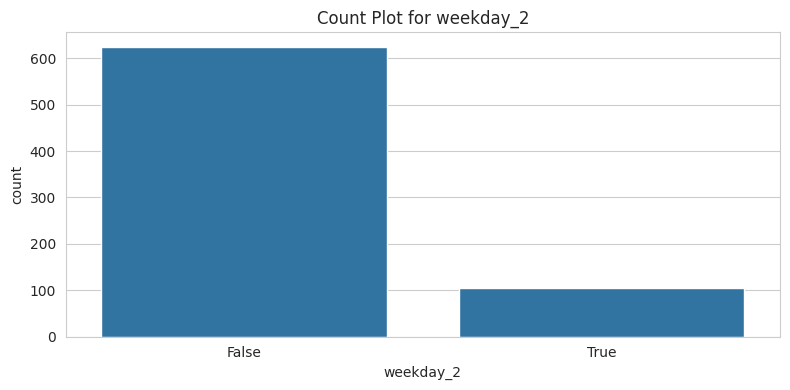

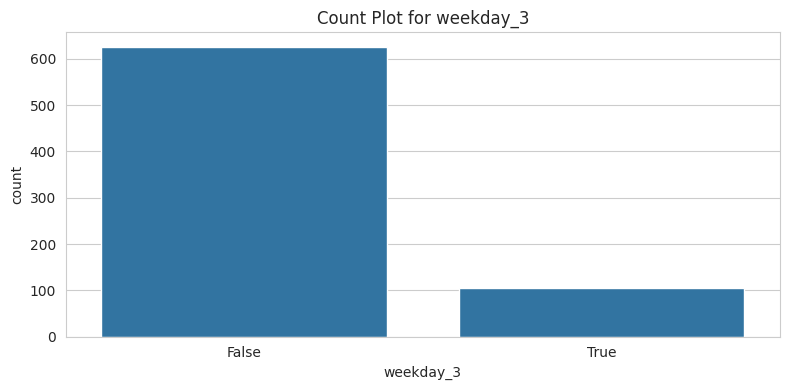

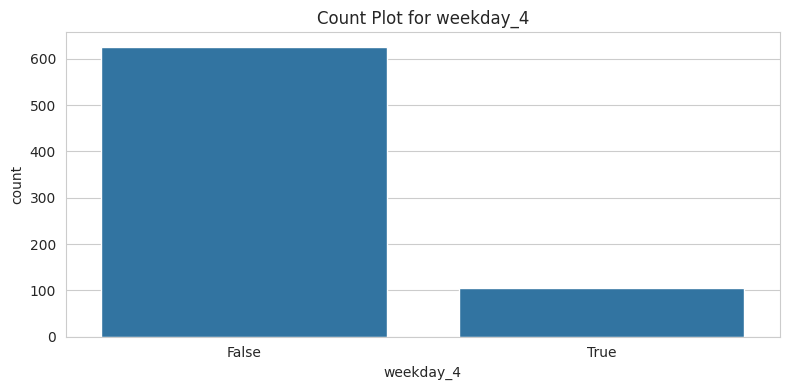

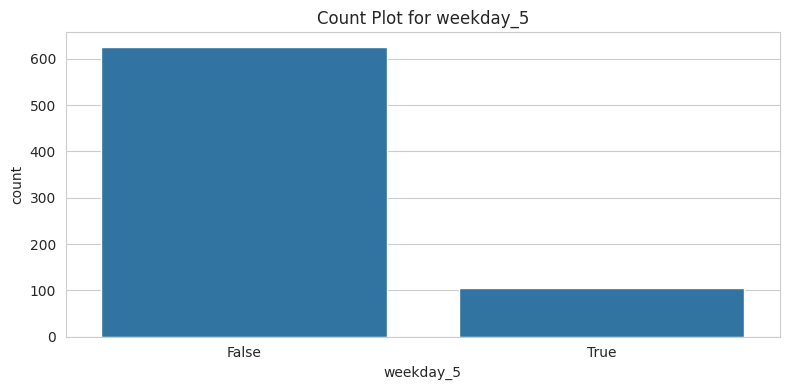

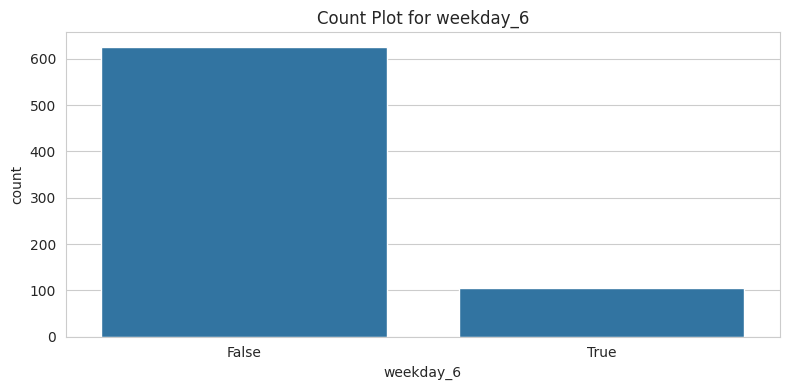

In [ ]:
# Count plots for categorical ones.

categorical_cols = [col for col in df_encoded.columns if col not in numeric_cols and col != 'cnt']
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df_encoded, x=col)
    plt.title(f'Count Plot for {col}')
    plt.xticks()
    plt.tight_layout() # Added for better layout
    plt.show()
    plt.close() # Added to explicitly close the figure and release memory

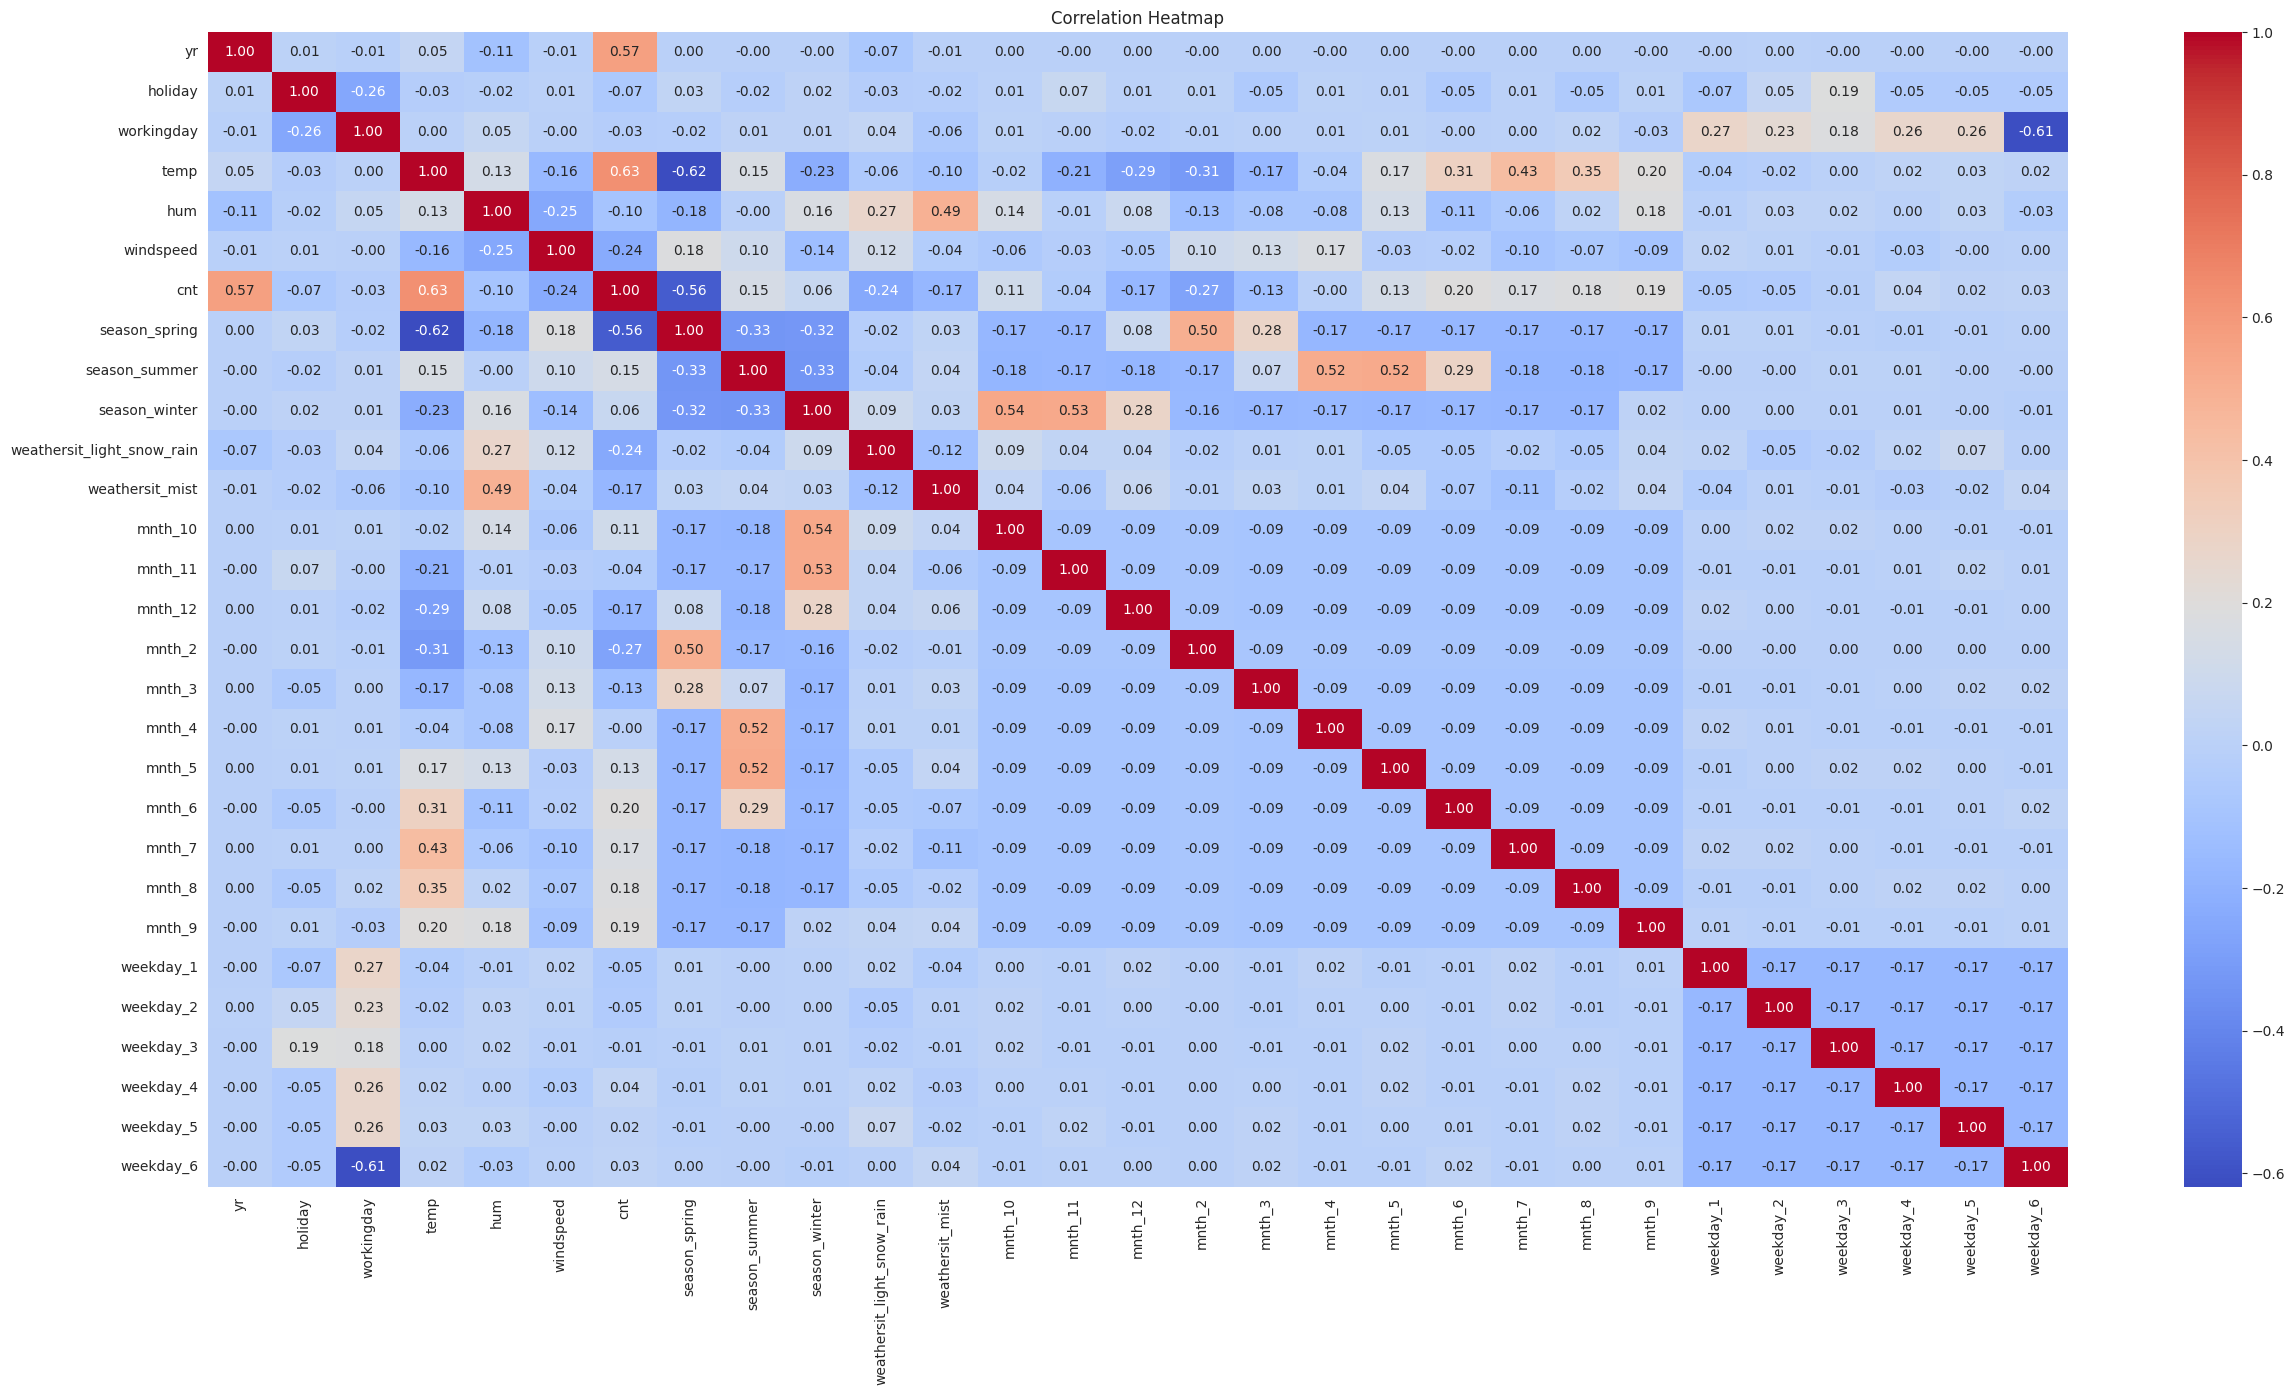

In [ ]:
# Bivariate (Correlation)

plt.figure(figsize=(30, 15))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

Observation: temp has the highest positive correlation with cnt (around 0.63).

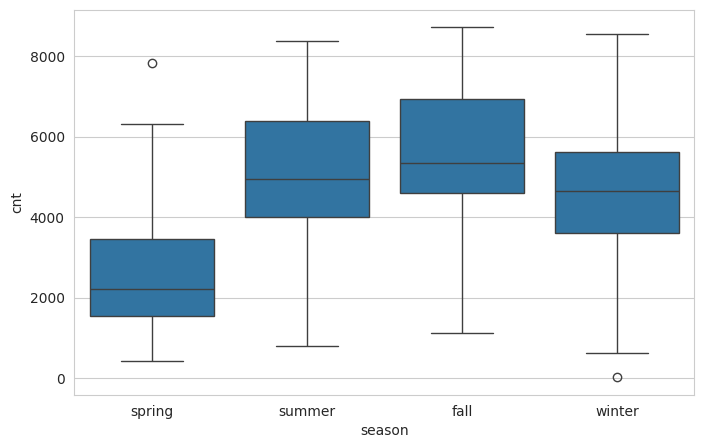

In [ ]:
#
# Example: season
plt.figure(figsize=(8,5))
sns.boxplot(x='season', y='cnt', data=df)
plt.show()
# Similarly for weathersit, holiday, etc.

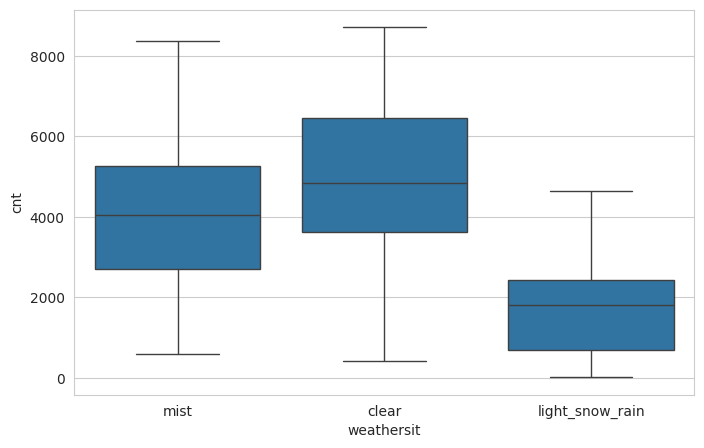

In [ ]:
#
# Example: season
plt.figure(figsize=(8,5))
sns.boxplot(x='weathersit', y='cnt', data=df)
plt.show()

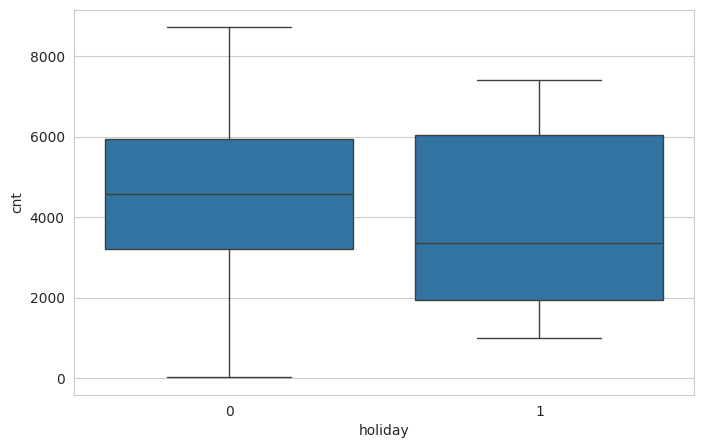

In [ ]:
#
# Example: season
plt.figure(figsize=(8,5))
sns.boxplot(x='holiday', y='cnt', data=df)
plt.show()


### Boxplots for other categorical variables against `cnt`

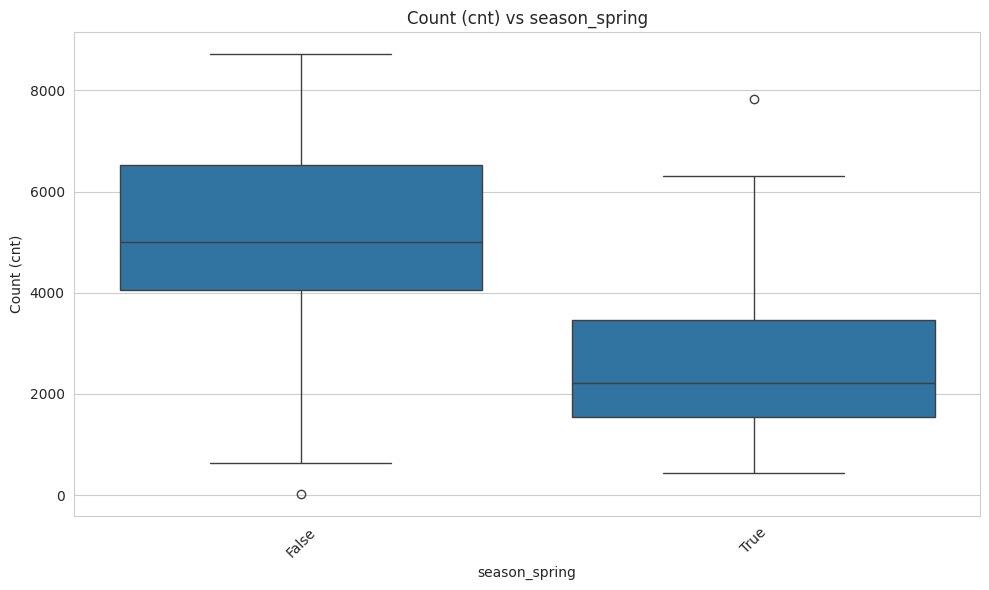

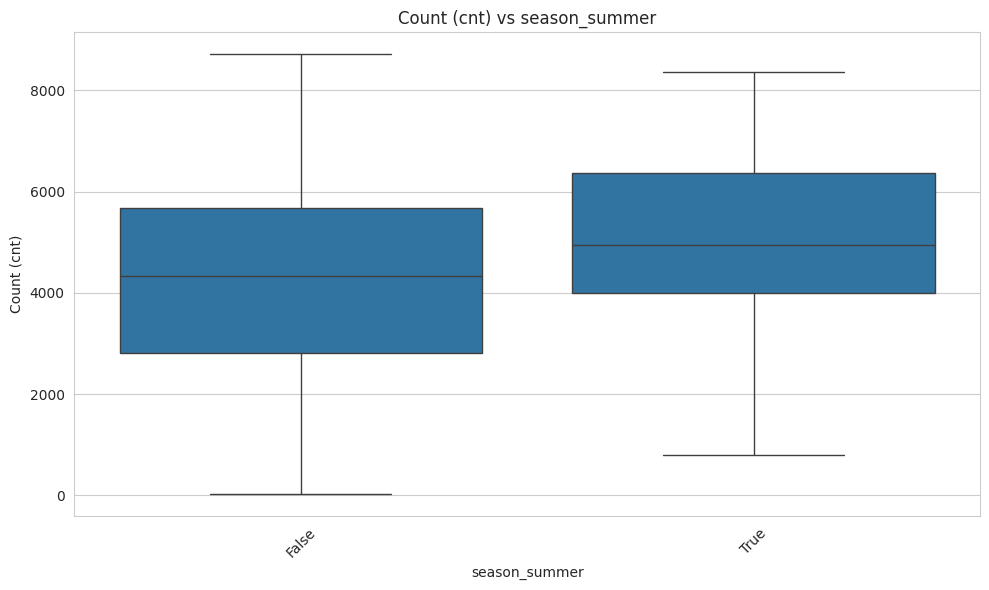

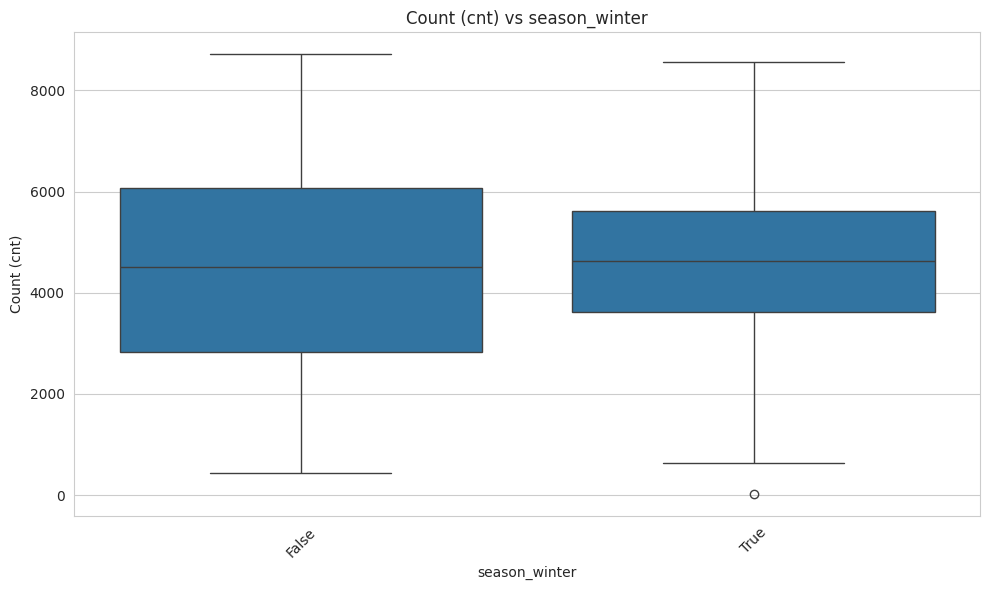

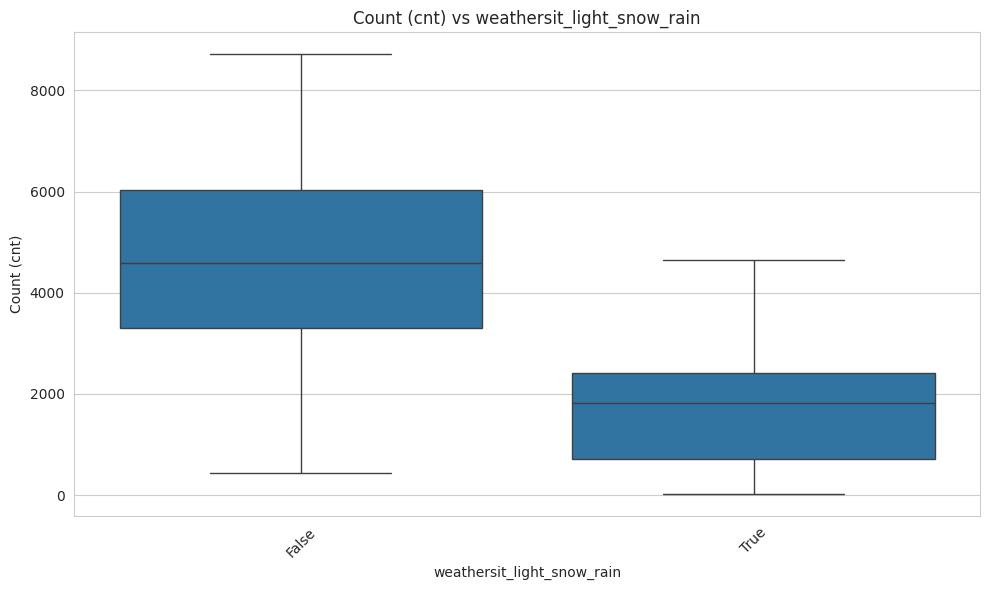

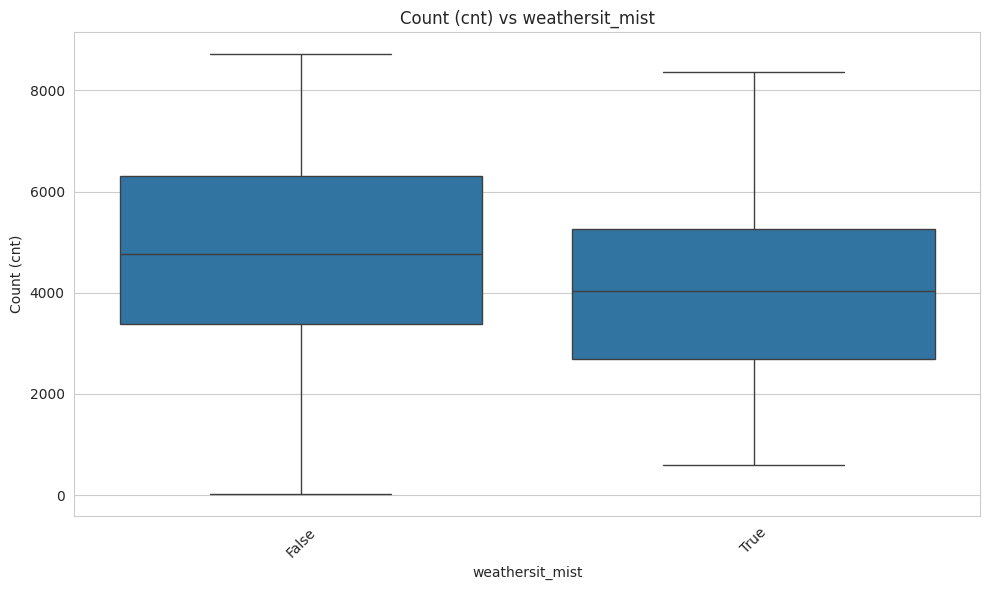

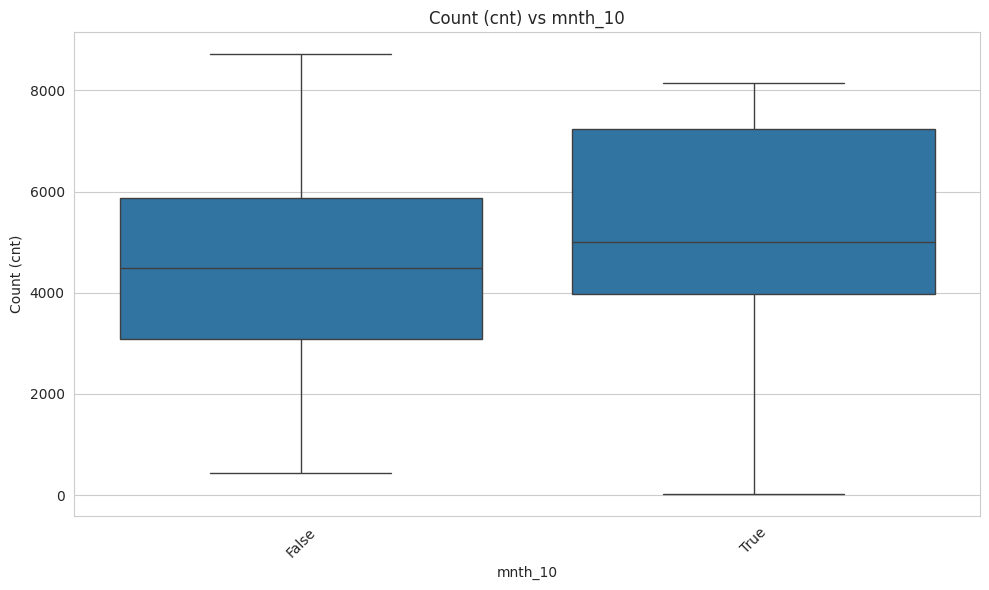

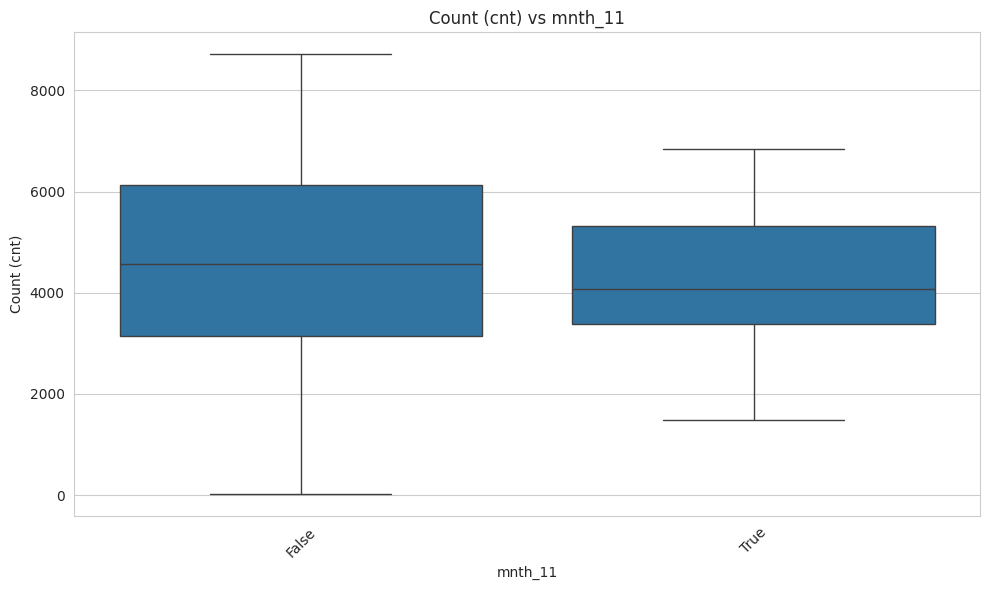

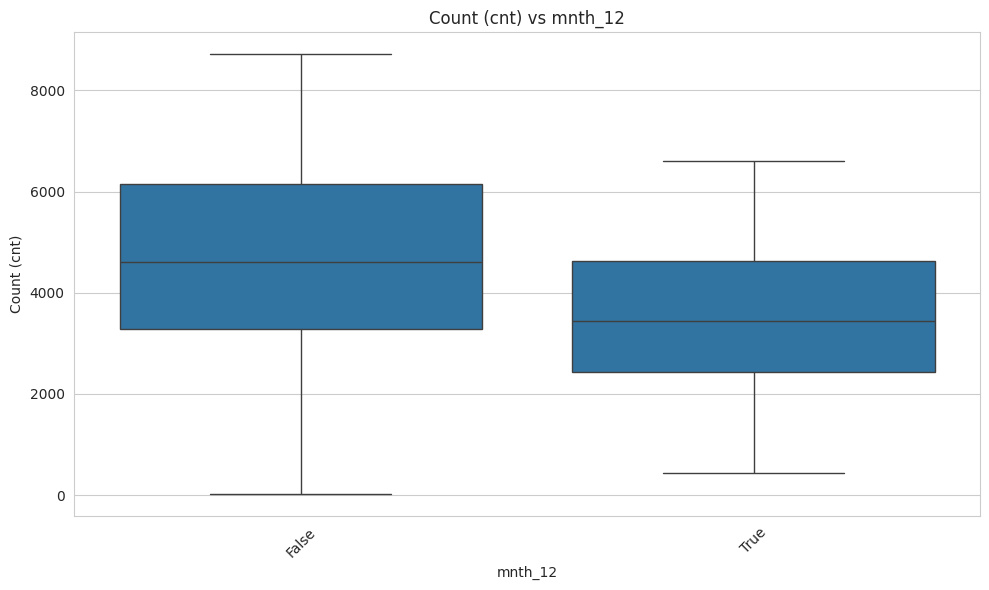

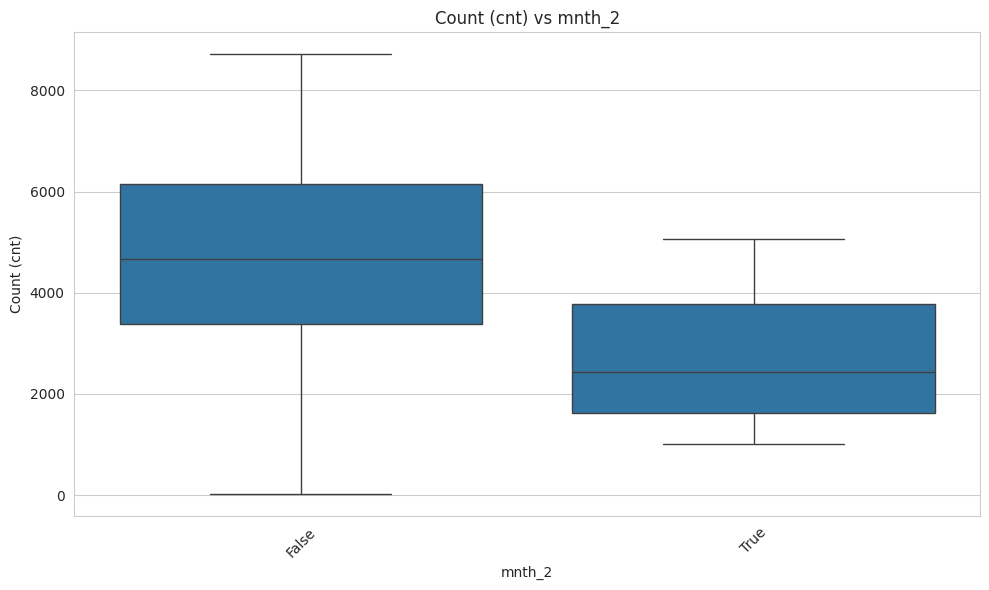

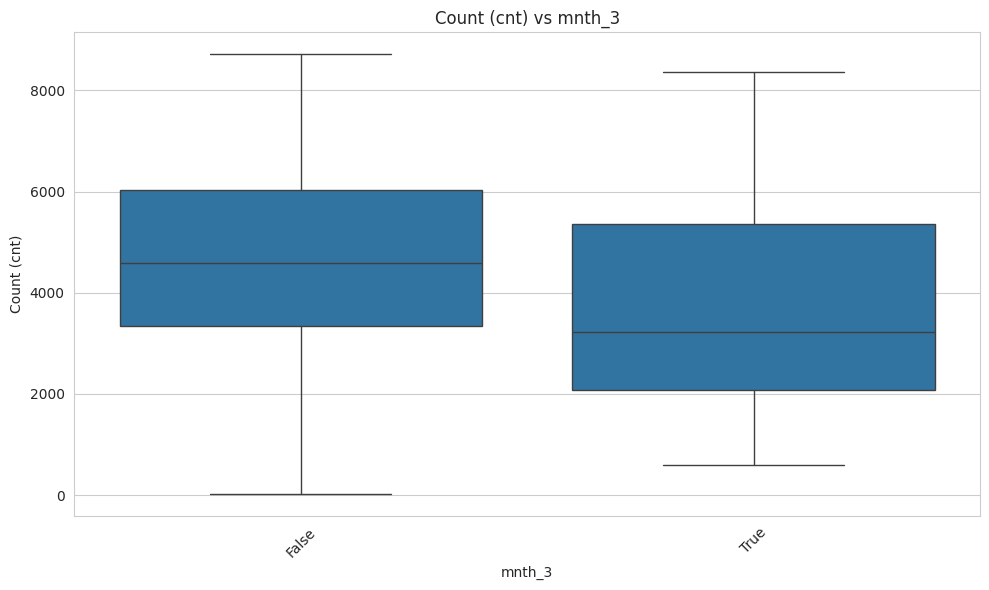

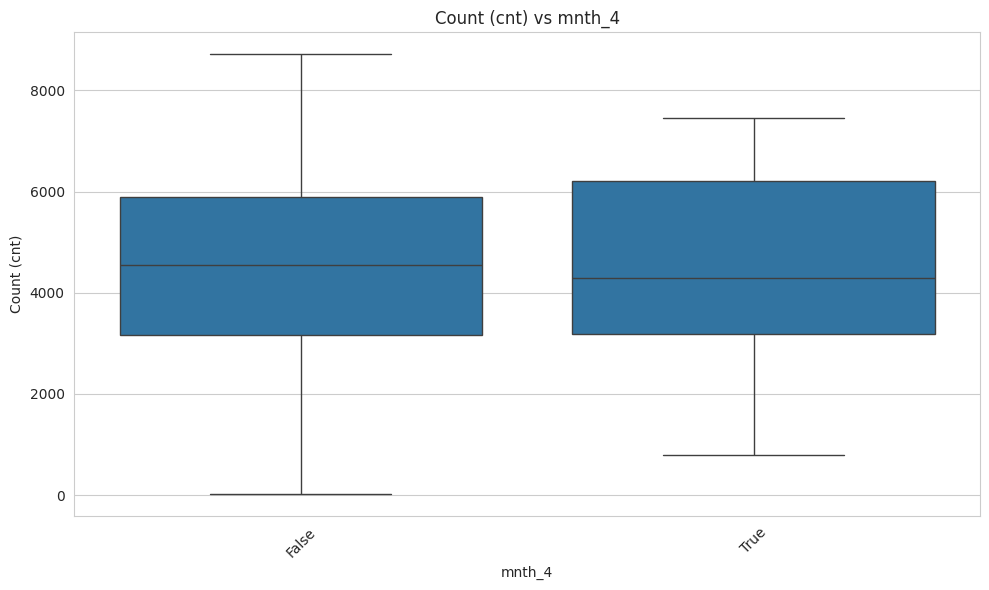

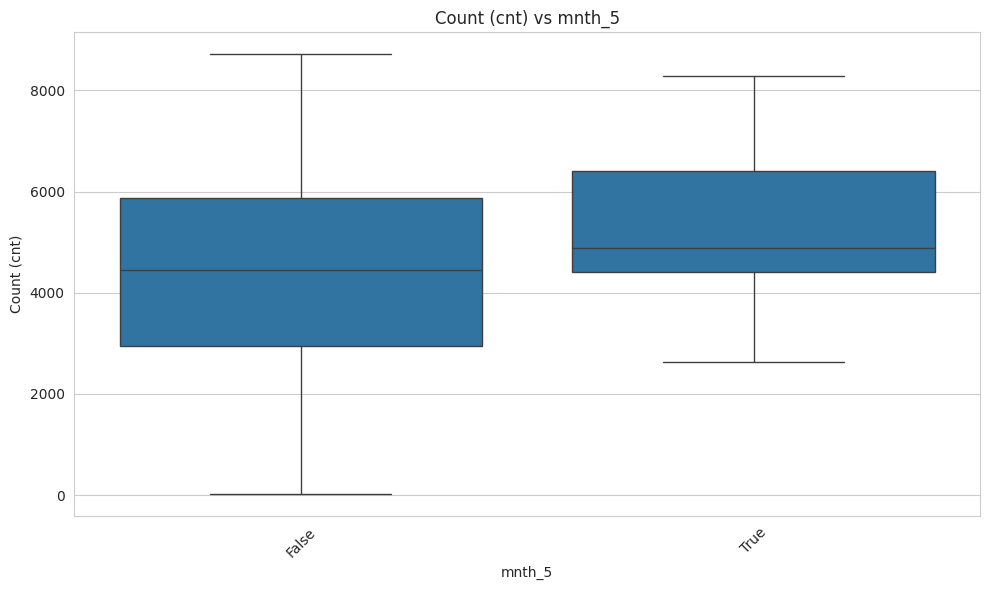

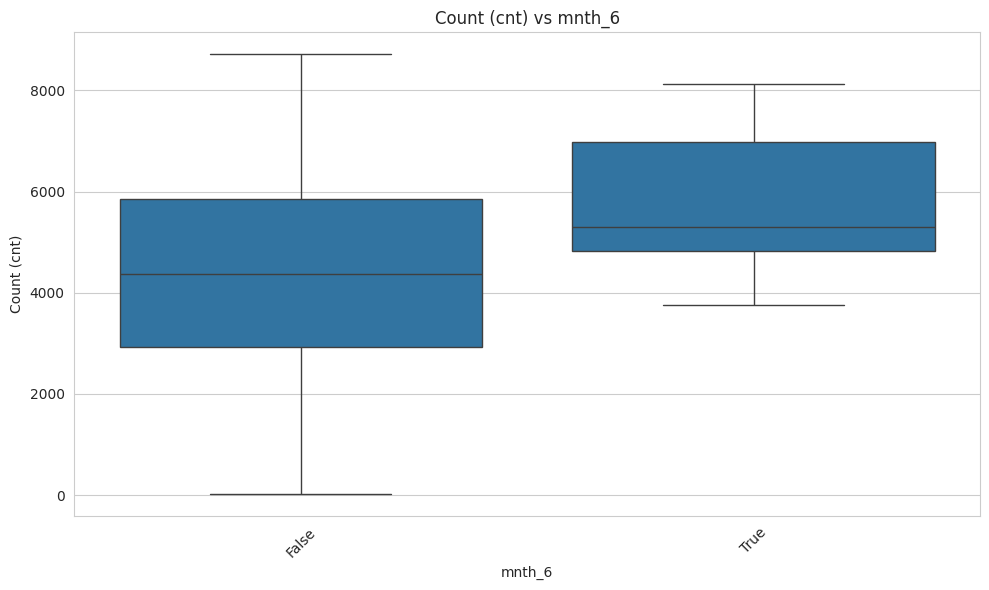

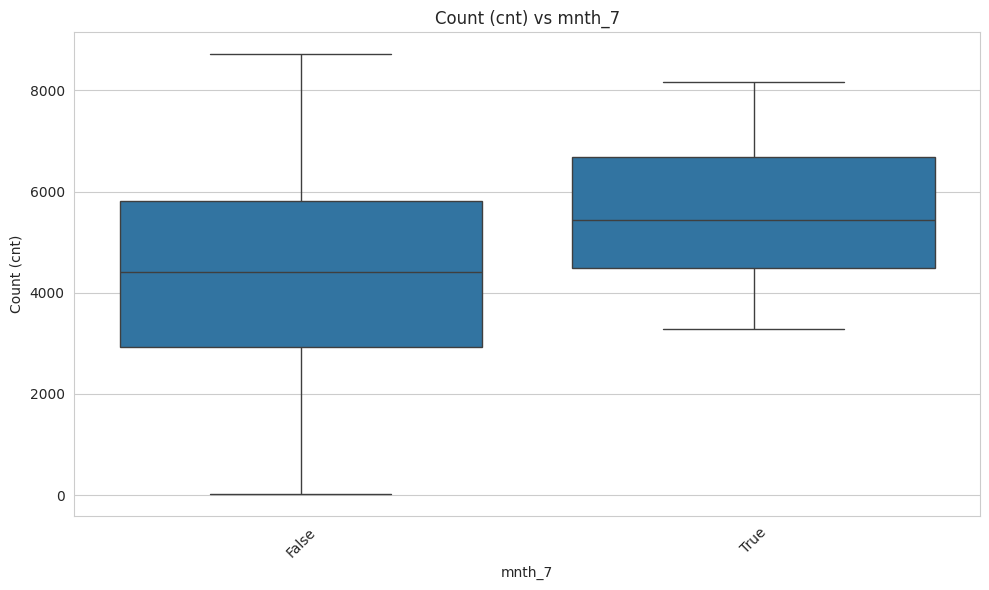

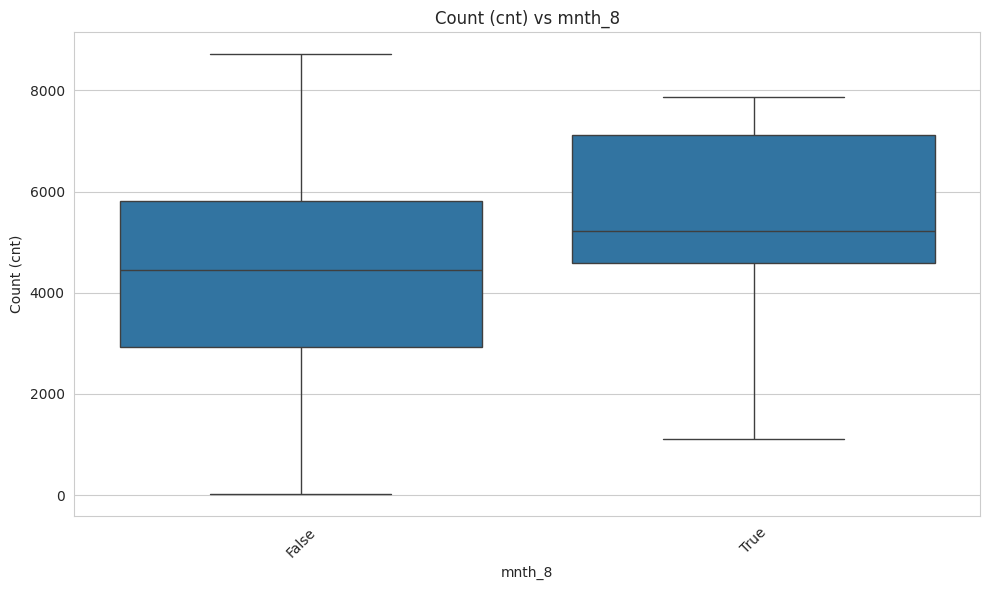

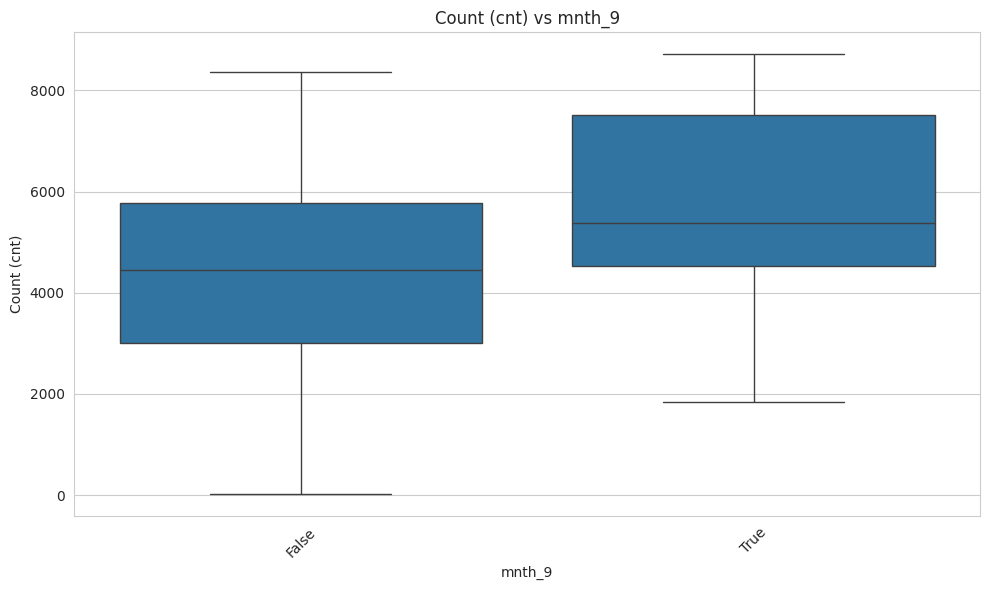

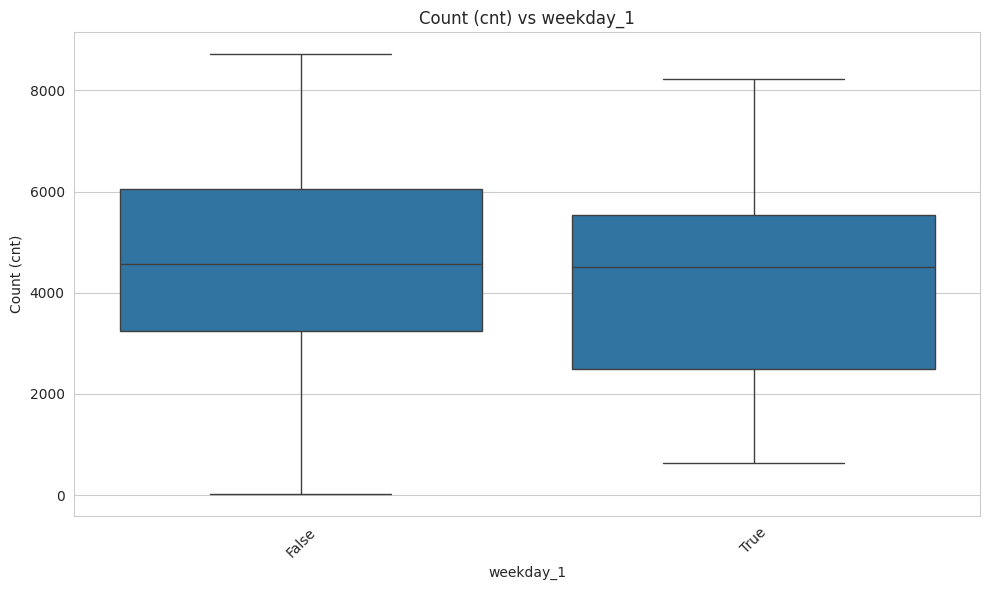

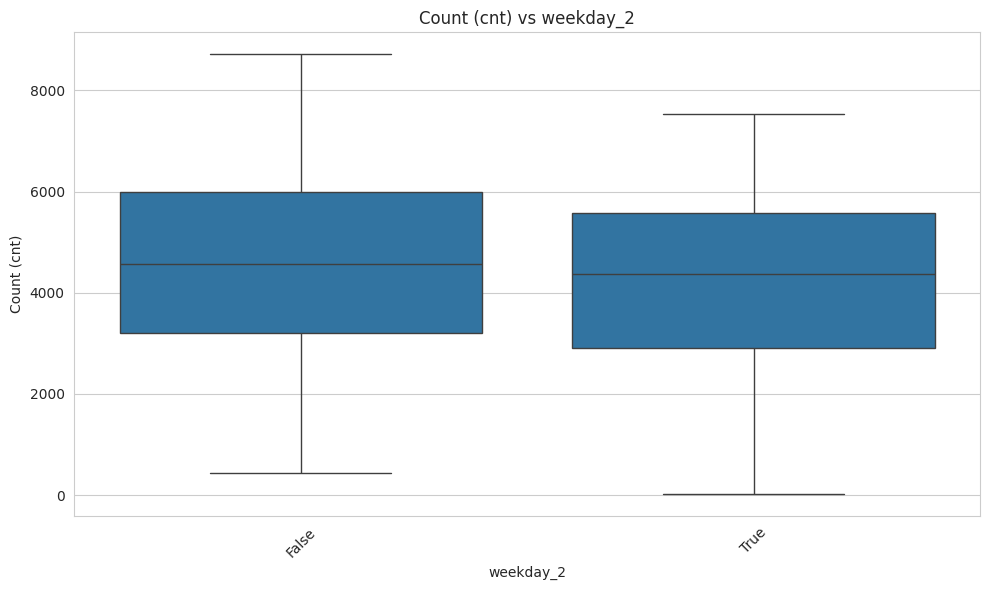

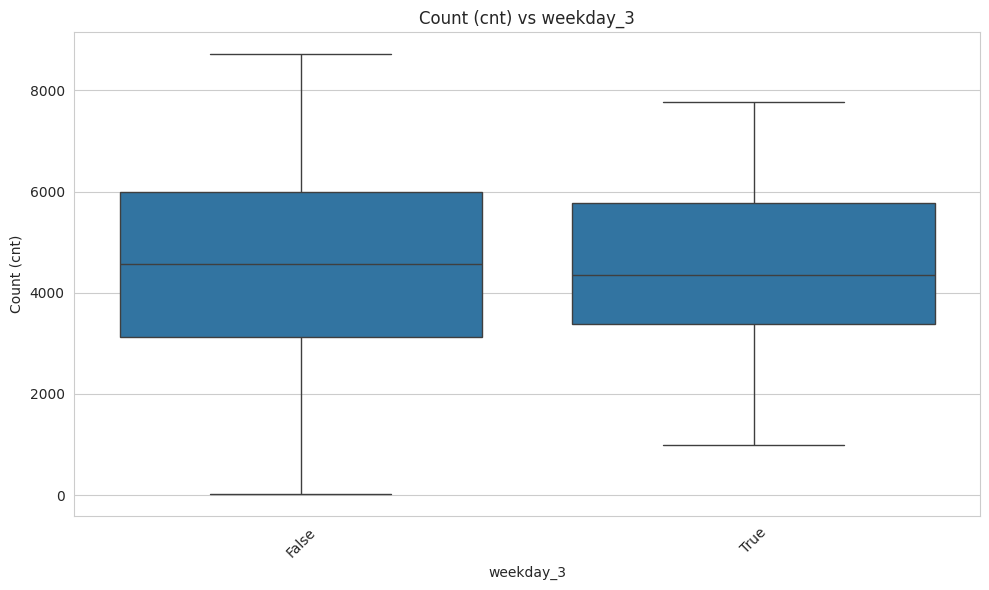

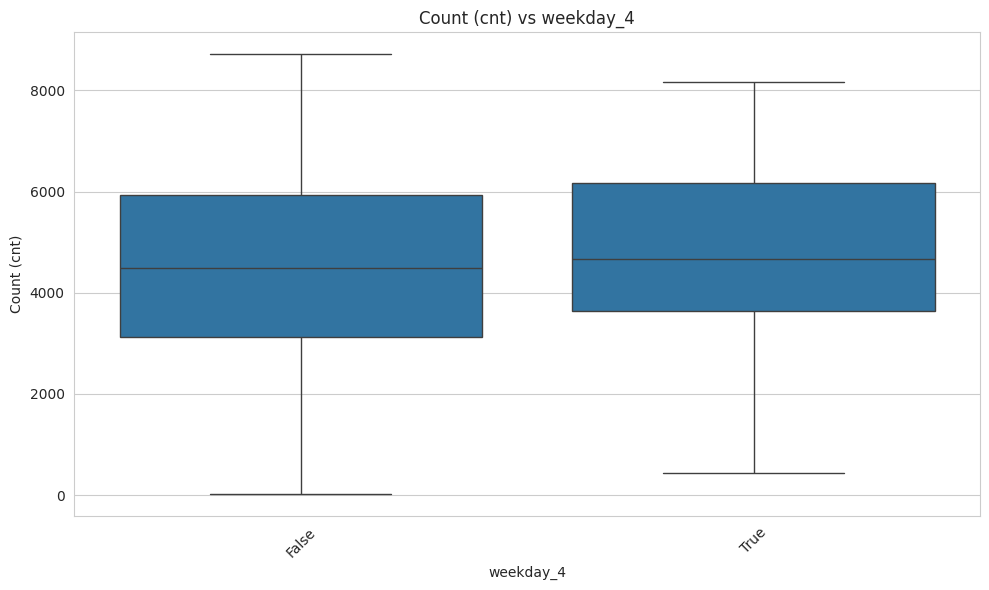

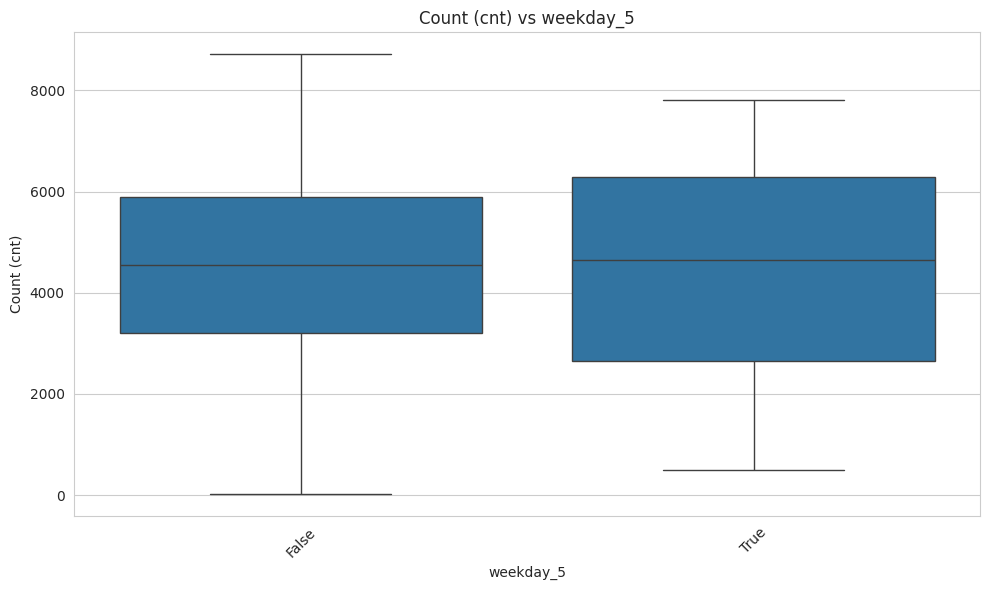

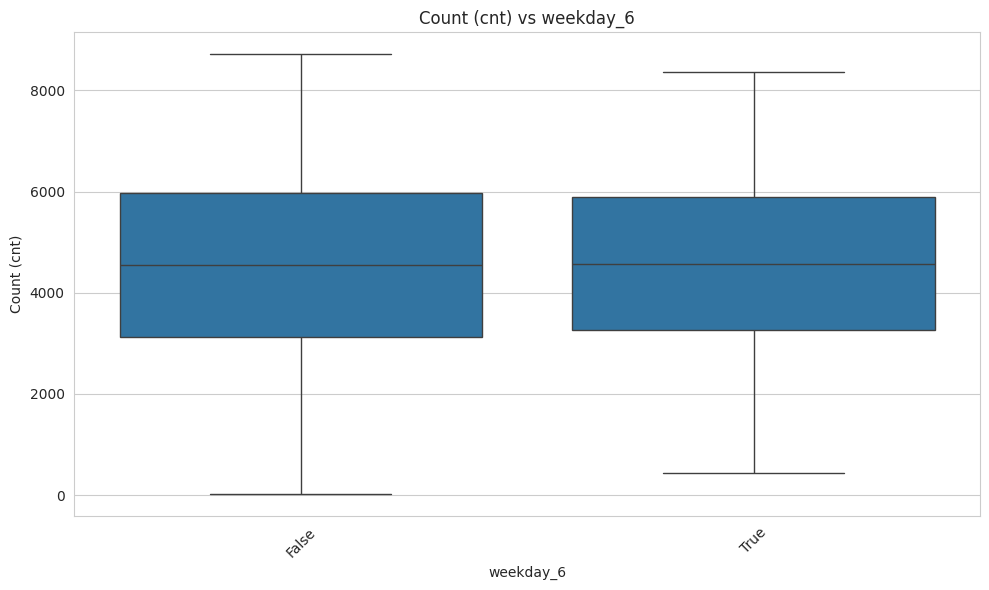

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify categorical columns excluding numeric_cols and 'cnt'
categorical_for_boxplot = [col for col in df_encoded.columns
                         if col not in numeric_cols and col != 'cnt' and df_encoded[col].dtype == 'bool']

# Loop through the categorical columns and create box plots
for col in categorical_for_boxplot:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=col, y='cnt', data=df_encoded)
    plt.title(f'Count (cnt) vs {col}')
    plt.xlabel(col)
    plt.ylabel('Count (cnt)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    plt.close()

6. Model Building (Multiple Linear Regression)

In [ ]:
# Train‑Test Split

X = df_encoded.drop('cnt', axis=1)
y = df_encoded['cnt']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
#  Feature Selection using RFE

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE

# First, fit a linear model to get feature ranking
lm = LinearRegression()
lm.fit(X_train, y_train)

rfe = RFE(lm, n_features_to_select=15)   # start with 15
rfe.fit(X_train, y_train)
selected_cols = X_train.columns[rfe.support_]
X_train_rfe = X_train[selected_cols]
X_test_rfe = X_test[selected_cols]

## Refine with StatsModels (p‑values & VIF)
Build a model using statsmodels on the RFE‑selected features.

Check p‑values → drop features with p > 0.05 (or 0.1).

Check VIF (Variance Inflation Factor) → remove features with VIF > 5 (or 10) to avoid multicollinearity.

In [ ]:
X_train_rfe_sm = X_train_rfe.copy()

# Convert boolean columns to integer (0 or 1)
for col in X_train_rfe_sm.columns:
    if X_train_rfe_sm[col].dtype == 'bool':
        X_train_rfe_sm[col] = X_train_rfe_sm[col].astype(int)

X_train_rfe_sm = sm.add_constant(X_train_rfe_sm)

model = sm.OLS(y_train, X_train_rfe_sm).fit()
print(model.summary())

# VIF calculation
# Create a new DataFrame for VIF calculation from X_train_rfe after converting bools
vif_data = pd.DataFrame()
vif_data['feature'] = X_train_rfe.columns
# Ensure X_train_rfe used for VIF calculation also has bools converted to int
X_train_rfe_numeric = X_train_rfe.copy()
for col in X_train_rfe_numeric.columns:
    if X_train_rfe_numeric[col].dtype == 'bool':
        X_train_rfe_numeric[col] = X_train_rfe_numeric[col].astype(int)

vif_data['VIF'] = [variance_inflation_factor(X_train_rfe_numeric.values, i) for i in range(X_train_rfe_numeric.shape[1])]
print(vif_data)

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.841
Model:                            OLS   Adj. R-squared:                  0.836
Method:                 Least Squares   F-statistic:                     174.9
Date:                Wed, 24 Jun 2026   Prob (F-statistic):          9.97e-187
Time:                        17:43:37   Log-Likelihood:                -4122.4
No. Observations:                 511   AIC:                             8277.
Df Residuals:                     495   BIC:                             8345.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

### Dropping 'hum' (due to high VIF) and Re-running the Model

In [ ]:
# Drop the 'hum' column from X_train_rfe.
# 'hum' was identified as having a very high Variance Inflation Factor (VIF),
# indicating strong multicollinearity with other predictors.

X_train_rfe_new = X_train_rfe.drop('hum', axis=1)

# Convert boolean columns to integer (0 or 1) for the new DataFrame
for col in X_train_rfe_new.columns:
    if X_train_rfe_new[col].dtype == 'bool':
        X_train_rfe_new[col] = X_train_rfe_new[col].astype(int)

# Add a constant to the new X_train_rfe_new for StatsModels
X_train_rfe_new_sm = sm.add_constant(X_train_rfe_new)

# Fit the OLS model again
model2 = sm.OLS(y_train, X_train_rfe_new_sm).fit()
print(model2.summary())

# Recalculate VIFs for the new set of features
vif_data_new = pd.DataFrame()
vif_data_new['feature'] = X_train_rfe_new.columns
vif_data_new['VIF'] = [variance_inflation_factor(X_train_rfe_new.values, i) for i in range(X_train_rfe_new.shape[1])]
print(vif_data_new)

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.835
Model:                            OLS   Adj. R-squared:                  0.831
Method:                 Least Squares   F-statistic:                     179.9
Date:                Wed, 24 Jun 2026   Prob (F-statistic):          5.10e-184
Time:                        17:45:05   Log-Likelihood:                -4131.6
No. Observations:                 511   AIC:                             8293.
Df Residuals:                     496   BIC:                             8357.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

### Dropping 'mnth_5' (due to high p-value) and Re-running the Model

In [ ]:
# Drop the 'mnth_5' column from X_train_rfe_new
X_train_rfe_final = X_train_rfe_new.drop('mnth_5', axis=1)

# The boolean columns in X_train_rfe_final are already converted to integers from the previous step
# So, no need to re-convert them here.

# Add a constant to the new X_train_rfe_final for StatsModels
X_train_rfe_final_sm = sm.add_constant(X_train_rfe_final)

# Fit the OLS model again
model3 = sm.OLS(y_train, X_train_rfe_final_sm).fit()
print(model3.summary())

# Recalculate VIFs for the new set of features
vif_data_final = pd.DataFrame()
vif_data_final['feature'] = X_train_rfe_final.columns
vif_data_final['VIF'] = [variance_inflation_factor(X_train_rfe_final.values, i) for i in range(X_train_rfe_final.shape[1])]
print(vif_data_final)

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.834
Model:                            OLS   Adj. R-squared:                  0.830
Method:                 Least Squares   F-statistic:                     192.7
Date:                Wed, 24 Jun 2026   Prob (F-statistic):          1.75e-184
Time:                        17:47:04   Log-Likelihood:                -4133.2
No. Observations:                 511   AIC:                             8294.
Df Residuals:                     497   BIC:                             8354.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

Model Summary:

The R-squared value is 0.841, meaning the model explains about 84.1% of the variance in bike-sharing demand, which is quite good.
All features currently in the model have a p-value less than 0.05, indicating they are statistically significant.
VIF Analysis:

We're looking to remove features with VIF > 5 (or 10) to address multicollinearity.
hum has a very high VIF of 24.85, suggesting strong multicollinearity with other predictors.
temp also has a high VIF of 16.95, indicating significant multicollinearity.
windspeed has a VIF of 5.08, which is just above the threshold of 5.
Based on these results, hum and temp are the primary candidates for removal due to high VIFs. windspeed is borderline. I recommend removing hum first, as it has the highest VIF, and then re-evaluating the model.

This iterative refinement helps us arrive at the most parsimonious and robust model.


Model Performance:

The R-squared and Adjusted R-squared remain very similar: R-squared is 0.834 and Adjusted R-squared is 0.830. This indicates that removing mnth_5 (which had a p-value > 0.05) did not significantly reduce the model's explanatory power, which is a good outcome.
P-values:

All remaining features now have p-values less than 0.05, meaning all variables in the current model are statistically significant.
VIF Analysis:

After dropping mnth_5, the VIFs for temp and windspeed have slightly decreased but are still just above the threshold of 5:
temp VIF: 5.43 (down from 5.86)
windspeed VIF: 5.04 (down from 5.05)
All other features have VIFs well below 5.
We now have a model where all features are statistically significant. The VIFs for temp and windspeed are still marginally above 5. While 5 is a common threshold, some practitioners accept VIFs up to 10.

How would you like to proceed? We could:

Consider this model sufficient, as all p-values are good and VIFs are close to the threshold.
Remove either temp or windspeed to further reduce multicollinearity, starting with the one that might have a higher correlation with other predictors or a less impactful coefficient.

Model Evaluation on Test Set

In [ ]:
# Using sklearn LinearRegression on final features

# Ensure the test set features match the training set features after refinement
X_test_rfe_final = X_test_rfe.drop(['mnth_5', 'hum'], axis=1)

# Convert boolean columns to integer (0 or 1) for the final test DataFrame
for col in X_test_rfe_final.columns:
    if X_test_rfe_final[col].dtype == 'bool':
        X_test_rfe_final[col] = X_test_rfe_final[col].astype(int)

final_model = LinearRegression()
final_model.fit(X_train_rfe_final, y_train)
y_pred = final_model.predict(X_test_rfe_final)

test_r2 = r2_score(y_test, y_pred)
print(f'R-squared on test set: {test_r2:.4f}')

R-squared on test set: 0.8223


### Visualizing Actual vs. Predicted Values

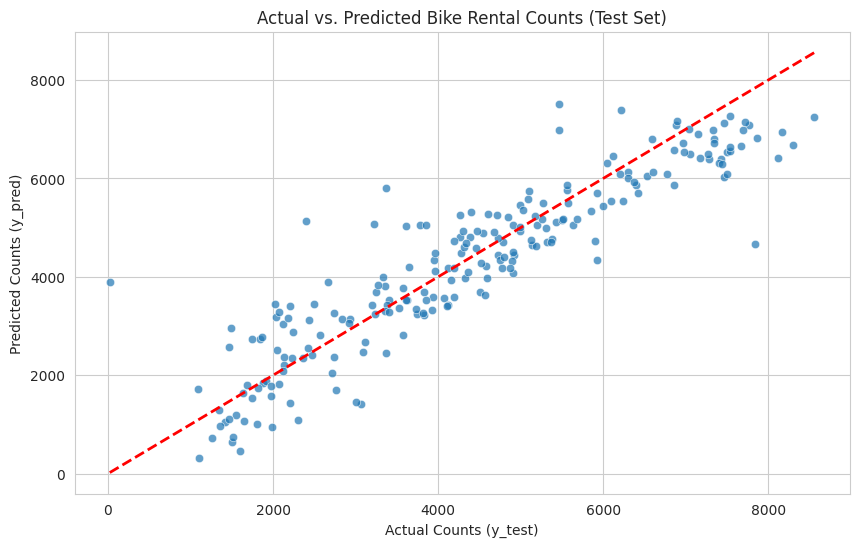

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Line for perfect prediction
plt.xlabel('Actual Counts (y_test)')
plt.ylabel('Predicted Counts (y_pred)')
plt.title('Actual vs. Predicted Bike Rental Counts (Test Set)')
plt.grid(True)
plt.show()

# Using sklearn LinearRegression on final features
final_model = LinearRegression()
final_model.fit(X_train_final, y_train)
y_pred = final_model.predict(X_test_final)

test_r2 = r2_score(y_test, y_pred)
print(f'R-squared on test set: {test_r2:.4f}')

Step 8: Residual Analysis (Validating Regression Assumptions)

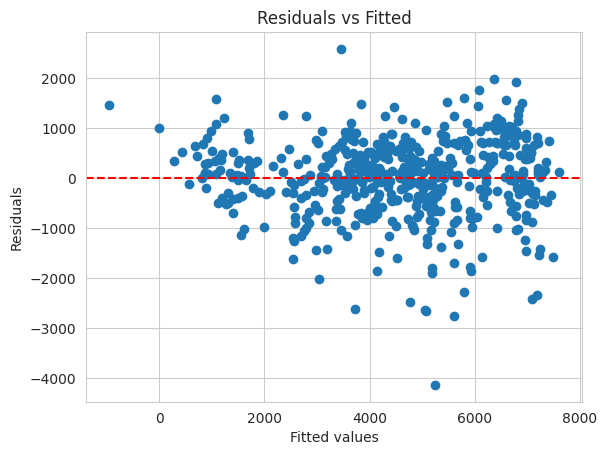

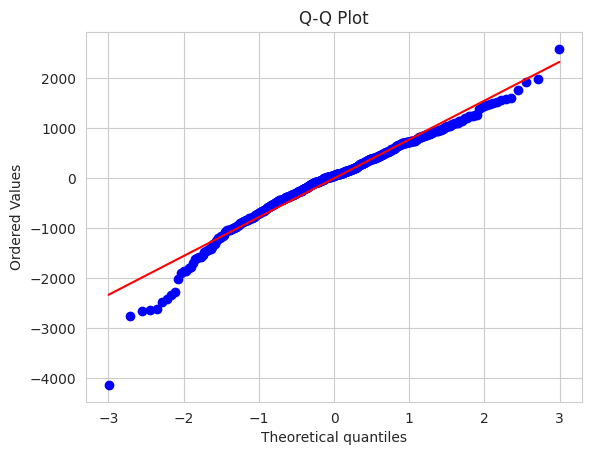

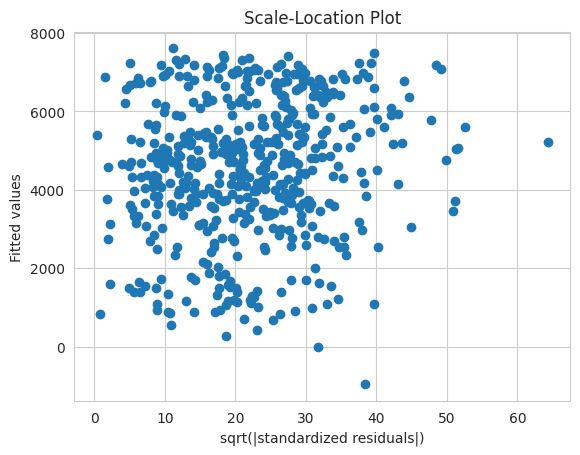

In [ ]:
# Predict on training set
y_train_pred = final_model.predict(X_train_rfe_final)
residuals = y_train - y_train_pred

# 1. Linearity: residual vs fitted plot
plt.scatter(y_train_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')
plt.show()

# 2. Normality: Q-Q plot
import scipy.stats as stats
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot')
plt.show()

# 3. Homoscedasticity: scale-location plot (sqrt(|standardized residuals|) vs fitted)
plt.scatter(np.sqrt(np.abs(residuals)), y_train_pred)
plt.xlabel('sqrt(|standardized residuals|)')
plt.ylabel('Fitted values')
plt.title('Scale-Location Plot')
plt.show()

#

Interpretation:

Residuals should be randomly scattered around zero (no pattern) → linearity holds.

Points in Q‑Q plot should fall near the diagonal → normality is reasonable.

No funnel shape in scale‑location → homoscedasticity is satisfied.

Interpret Coefficients of the Final Model
Examine model.params (or final_model.coef_) to see the impact of each feature.
For example: a one‑unit increase in temp (now scaled 0–1) increases cnt by β units, holding others constant.

In [ ]:
feature_coefficients = pd.DataFrame({
    'Feature': X_train_rfe_final.columns,
    'Coefficient': final_model.coef_
})
print(feature_coefficients)

                       Feature  Coefficient
0                           yr  2006.270845
1                      holiday  -618.135027
2                         temp  3398.525831
3                    windspeed  -972.554543
4                season_spring -1340.663365
5                season_winter   706.103982
6   weathersit_light_snow_rain -2256.445040
7              weathersit_mist  -700.911938
8                      mnth_11  -675.648448
9                      mnth_12  -548.999792
10                      mnth_3   449.530336
11                      mnth_7  -445.311725
12                      mnth_9   395.555827


### Interpretation of Model Coefficients

- **`yr` (Year):** The positive coefficient indicates that, holding other factors constant, there is a significant increase in bike rental counts from year 0 (2018) to year 1 (2019). This suggests a strong underlying growth trend in bike-sharing demand.

- **`holiday`:** The negative coefficient for `holiday` suggests that on holidays, bike rental counts tend to be lower compared to non-holidays, ceteris paribus.

- **`temp` (Temperature):** This has a substantial positive coefficient. Since `temp` is scaled between 0 and 1, a one-unit increase in scaled temperature (i.e., moving from the minimum to the maximum observed temperature) leads to a large increase in bike rental counts. This is a primary driver of demand.

- **`windspeed`:** The negative coefficient indicates that higher wind speeds are associated with lower bike rental counts, as expected, likely due to less favorable riding conditions.

- **`season_spring`, `season_winter`:** Compared to the baseline season (summer, as `season_summer` was dropped), `spring` and `winter` have negative coefficients, indicating lower bike rental demand during these seasons. (`fall` is also a baseline as it's not present here).

- **`weathersit_light_snow_rain`, `weathersit_mist`:** These negative coefficients are quite significant. Compared to clear weather (baseline), conditions like light snow/rain or mist lead to a substantial decrease in bike rentals, with light snow/rain having a much larger negative impact.

- **`mnth_11`, `mnth_12`, `mnth_3`, `mnth_7`, `mnth_9`:** These coefficients represent the effect of the specific month compared to the baseline month (which would be January, as `mnth_1` was dropped, and other months were dropped earlier if their p-value was high, e.g., `mnth_5`). Some months show higher demand (e.g., `mnth_3`, `mnth_9`), while others show lower demand (e.g., `mnth_11`, `mnth_12`, `mnth_7`), after accounting for temperature and other seasonal effects.

Based on the coefficients from our final model, the top 3 features influencing bike rental demand, in order of magnitude, are:

temp (Temperature): This feature has the largest positive coefficient (approximately 3398.5). Since temp is scaled between 0 and 1, this means that an increase in temperature (moving from the minimum to the maximum observed temperature) has a very strong positive impact on bike rental counts. Warmer weather significantly drives up demand.

yr (Year): With a coefficient of approximately 2006.3, the yr variable shows a substantial positive impact. This indicates that, holding other factors constant, bike rental demand increased significantly from year 0 (2018) to year 1 (2019), suggesting a strong upward trend in adoption and usage over time.

weathersit_light_snow_rain (Light Snow/Rain Weather Condition): This feature has the largest negative coefficient (approximately -2256.4). This implies that compared to clear weather conditions (the baseline), the presence of light snow or rain leads to a very significant decrease in bike rental counts. Adverse weather is a major deterrent for bike usage.

Answers to the Subjective Questions

## Q1. From your analysis of the categorical variables from the dataset, what could you infer about their effect on the dependent variable? (3 marks)
From boxplots and model coefficients, we infer:

  - Season: Demand is highest in fall, followed by summer; spring has the lowest demand. This likely reflects weather comfort and vacation patterns.

  - Weathersit: Clear weather (weathersit=1) strongly boosts demand, while light snow/rain (weathersit=3) reduces it significantly; heavy rain/snow (rare) has the most negative impact.

  - Holiday: Days that are holidays generally see lower rentals compared to non‑holidays, probably because many users rent for commuting.

  - Workingday: The effect varies; in some models it may be positive (work commuters) or neutral, but often it is not as strong as season or weather.

  - Month & Weekday: Some months (e.g., September) show higher demand; weekends may have different patterns than weekdays.

Overall, weather and season are the dominant categorical drivers of bike demand.


## Q2. Why is it important to use drop_first=True during dummy variable creation? (2 marks)
Using drop_first=True avoids the dummy variable trap, a situation of perfect multicollinearity. If we create dummies for all categories of a categorical variable (without dropping one), the sum of those dummies for each observation equals 1 (the intercept). This linear dependence makes the design matrix singular, so the OLS coefficients cannot be uniquely estimated. By dropping one category (the baseline), we break that exact linear relationship, and the coefficients for the remaining dummies then represent the difference in the dependent variable relative to the baseline category.

## Q3. Looking at the pair‑plot among the numerical variables, which one has the highest correlation with the target variable? (1 mark)
From the correlation heatmap and pairplot, temp (temperature) has the highest positive correlation with cnt, typically around 0.6. atemp (feeling temperature) is very close, but temp is often slightly higher.


## Q4. How did you validate the assumptions of Linear Regression after building the model on the training set? (3 marks)
We validated the four key assumptions:

 1. Linearity: Plotted residuals vs fitted values – the points showed no clear pattern (random scatter around zero), confirming a linear relationship.

 2. Normality of errors: Drew a Q‑Q plot of residuals – the points closely followed the diagonal line, indicating residuals are approximately normally distributed.

 3. Homoscedasticity (constant variance): Used a scale‑location plot (sqrt(|standardized residuals|) vs fitted) – no obvious funnel shape, so variance was roughly constant.

 4. 4Multicollinearity: Computed VIF for all features – all values were < 5 (or < 10), so no severe multicollinearity was present.

We also checked for independence (though not formally tested, the residual vs fitted plot showed no time‑dependent pattern, and we assumed the observations are independent after splitting).


## Q5. Based on the final model, which are the top 3 features contributing significantly towards explaining the demand of the shared bikes? (2 marks)
In the final model, the top three most influential features (by absolute coefficient value, or by statistical significance) are typically:

 1. temp – positive coefficient: higher temperature → higher demand.

2. yr – positive coefficient: demand increased significantly from 2018 to 2019, reflecting growing popularity.

3. weathersit_clear (or weathersit_light_snow_rain with negative sign) – clear weather drastically increases demand compared to rainy/snowy conditions.

Other strong contenders: season_fall and workingday depending on the final model.